# Практическая работа 5-6. Классификация: SVM, kNN, Random Forest

---

**Дисциплина:** Интеллектуальные системы и технологии  
**Университет:** РТУ МИРЭА  
**Преподаватель:** Демидова Л.А.  
**Вариант:** 20  
**Набор данных:** Statlog (Australian Credit Approval), UCI Machine Learning Repository  
**Ссылка на датасет:** https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/australian/australian.dat

---

## Цель работы

Изучение и практическое применение методов классификации на основе метода опорных векторов (SVM), метода k ближайших соседей (kNN) и алгоритма случайного леса (Random Forest). Проводится анализ набора данных Statlog Australian Credit Approval, содержащего информацию о заявках на получение кредита. Целевая переменная принимает два значения: **0** — отказ в выдаче кредита, **1** — одобрение кредита.

---

## Описание набора данных

| Параметр | Значение |
|---|---|
| Источник | UCI Machine Learning Repository |
| Название | Statlog (Australian Credit Approval) |
| Количество объектов | 690 |
| Количество признаков | 14 (A1–A14) |
| Тип задачи | Бинарная классификация |
| Классы | 0 — отказ, 1 — одобрение |

**Категориальные признаки:** A1, A4, A5, A6, A8, A9, A11, A12  
**Числовые признаки:** A2, A3, A7, A10, A13, A14

---

## Применяемые классификаторы

- **Часть A — SVM (Support Vector Machine):** исследование ядер (линейное, RBF, полиномиальное, сигмоидальное), подбор гиперпараметров C и gamma методом Grid Search, подсчёт опорных векторов.
- **Часть B — kNN (k Nearest Neighbors):** исследование различных значений k, метрик расстояния и правил голосования, подбор гиперпараметров методом Grid Search.
- **Часть C — Random Forest:** подбор n_estimators и max_depth методом Grid Search, визуализация двух деревьев из ансамбля.

---

## Метрики качества классификации

Для каждого классификатора вычисляются следующие метрики на обучающей и тестовой выборках:

- **Accuracy** — доля правильно классифицированных объектов
- **Recall** — полнота (чувствительность)
- **Precision** — точность
- **F1-score** — гармоническое среднее точности и полноты

---

## Разбиение выборки

Данные разбиваются на обучающую и тестовую выборки в соотношении **80% / 20%** (стратифицированное разбиение для сохранения распределения классов).

---

## Алгоритмы визуализации (снижение размерности)

Для визуализации многомерных данных в двумерном пространстве применяются:

- **t-SNE** (t-distributed Stochastic Neighbor Embedding)
- **UMAP** (Uniform Manifold Approximation and Projection)
- **TriMAP**
- **PaCMAP** (Pairwise Controlled Manifold Approximation)

Визуализация выполняется как по истинным меткам классов, так и по предсказаниям классификаторов. Для SVM дополнительно отображаются опорные векторы.

In [1]:
# Установка необходимых библиотек для работы
!pip install scikit-learn umap-learn trimap pacmap pandas numpy matplotlib seaborn graphviz


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Инструменты для подбора гиперпараметров и разбиения выборки
from sklearn.model_selection import GridSearchCV, train_test_split, cross_val_score

from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.manifold import TSNE
import umap
import trimap
import pacmap

# Визуализация деревьев решений
from sklearn.tree import export_graphviz
import graphviz

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 8)

# Фиксация зерна генератора случайных чисел для воспроизводимости результатов
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Часть 1. Загрузка и подготовка данных

Набор данных **Statlog (Australian Credit Approval)** содержит **690 объектов** и **14 признаков** (A1–A14), описывающих заявки на получение кредита. Признаки представлены смешанным типом: категориальные (A1, A4, A5, A6, A8, A9, A11, A12) и числовые (A2, A3, A7, A10, A13, A14). Целевая переменная является бинарной: **0** — отказ в выдаче кредита, **1** — одобрение кредита.

Данные разбиваются на обучающую и тестовую выборки в соотношении **80% / 20%** (стратифицированное разбиение). Стратификация обеспечивает сохранение исходного соотношения классов в обеих подвыборках, что критически важно при несбалансированных классах.

In [3]:
# Адрес набора данных в репозитории UCI
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/australian/australian.dat'

# Путь к локальной копии файла (используется при недоступности UCI)
import os
local_path = 'australian.dat'
if not os.path.exists(local_path):
    local_path = os.path.join(os.path.dirname(os.path.abspath('.')), 'practice_05_06', 'australian.dat')

column_names = [f'A{i}' for i in range(1, 15)] + ['class']

try:
    df = pd.read_csv(url, sep=' ', header=None, names=column_names)
    print('Данные загружены с UCI.')
except Exception:
    df = pd.read_csv(local_path, sep=' ', header=None, names=column_names)
    print('Данные загружены из локального файла.')

# Размер датасета
print('Размер датасета:', df.shape)

# Типы данных столбцов
print('\nТипы данных:')
print(df.dtypes)

# Первые 5 строк набора данных
print('\nПервые 5 строк:')
print(df.head())

print('\nКоличество пропущенных значений по столбцам:')
print(df.isnull().sum())

Данные загружены с UCI.
Размер датасета: (690, 15)

Типы данных:
A1         int64
A2       float64
A3       float64
A4         int64
A5         int64
A6         int64
A7       float64
A8         int64
A9         int64
A10        int64
A11        int64
A12        int64
A13        int64
A14        int64
class      int64
dtype: object

Первые 5 строк:
   A1     A2     A3  A4  A5  A6     A7  A8  A9  A10  A11  A12  A13   A14  \
0   1  22.08  11.46   2   4   4  1.585   0   0    0    1    2  100  1213   
1   0  22.67   7.00   2   8   4  0.165   0   0    0    0    2  160     1   
2   0  29.58   1.75   1   4   4  1.250   0   0    0    1    2  280     1   
3   0  21.67  11.50   1   5   3  0.000   1   1   11    1    2    0     1   
4   1  20.17   8.17   2   6   4  1.960   1   1   14    0    2   60   159   

   class  
0      0  
1      0  
2      0  
3      1  
4      1  

Количество пропущенных значений по столбцам:
A1       0
A2       0
A3       0
A4       0
A5       0
A6       0
A7       0
A8 

In [4]:
# Категориальные признаки, требующие кодирования
categorical_cols = ['A1', 'A4', 'A5', 'A6', 'A8', 'A9', 'A11', 'A12']

le = LabelEncoder()
df_encoded = df.copy()
for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

X = df_encoded[[f'A{i}' for i in range(1, 15)]].values
y = df_encoded['class'].values

# Размеры матрицы признаков и вектора меток
print('Размер матрицы признаков X:', X.shape)
print('Размер вектора меток y:', y.shape)

# Распределение классов
unique, counts = np.unique(y, return_counts=True)
print('\nРаспределение классов:')
for cls, cnt in zip(unique, counts):
    label = 'одобрение' if cls == 1 else 'отказ'
    print(f'  Класс {cls} ({label}): {cnt} объектов ({cnt / len(y) * 100:.1f}%)')

Размер матрицы признаков X: (690, 14)
Размер вектора меток y: (690,)

Распределение классов:
  Класс 0 (отказ): 383 объектов (55.5%)
  Класс 1 (одобрение): 307 объектов (44.5%)


In [5]:
# Разбиение на обучающую и тестовую выборки (80% / 20%, стратифицированное)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

# Масштабирование признаков: обучение на тренировочной выборке, применение к обеим
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Размеры обучающей и тестовой выборок
print('Размер обучающей выборки:', X_train.shape)
print('Размер тестовой выборки: ', X_test.shape)

# Распределение классов в обучающей выборке
unique_tr, counts_tr = np.unique(y_train, return_counts=True)
print('\nРаспределение классов в обучающей выборке:')
for cls, cnt in zip(unique_tr, counts_tr):
    label = 'одобрение' if cls == 1 else 'отказ'
    print(f'  Класс {cls} ({label}): {cnt} объектов ({cnt / len(y_train) * 100:.1f}%)')

# Распределение классов в тестовой выборке
unique_te, counts_te = np.unique(y_test, return_counts=True)
print('\nРаспределение классов в тестовой выборке:')
for cls, cnt in zip(unique_te, counts_te):
    label = 'одобрение' if cls == 1 else 'отказ'
    print(f'  Класс {cls} ({label}): {cnt} объектов ({cnt / len(y_test) * 100:.1f}%)')

Размер обучающей выборки: (552, 14)
Размер тестовой выборки:  (138, 14)

Распределение классов в обучающей выборке:
  Класс 0 (отказ): 306 объектов (55.4%)
  Класс 1 (одобрение): 246 объектов (44.6%)

Распределение классов в тестовой выборке:
  Класс 0 (отказ): 77 объектов (55.8%)
  Класс 1 (одобрение): 61 объектов (44.2%)


### Итоги подготовки данных

После загрузки и предобработки набор данных разбит на **обучающую выборку** (552 объекта, 80%) и **тестовую выборку** (138 объектов, 20%). Категориальные признаки (A1, A4, A5, A6, A8, A9, A11, A12) закодированы с помощью `LabelEncoder`, что позволяет корректно передать их в алгоритмы классификации.

Масштабирование выполнено методом **стандартизации** (`StandardScaler`): параметры (среднее и стандартное отклонение) вычислены исключительно на обучающей выборке, после чего применены к обеим подвыборкам. Это исключает утечку информации из тестовой выборки в процессе обучения.

Стратифицированное разбиение (`stratify=y`) гарантирует сохранение исходного соотношения классов в каждой подвыборке. Данная мера особенно важна при несбалансированных классах: без стратификации случайное разбиение может привести к значительному отклонению пропорций классов, что искажает оценку качества модели.

## Часть A. Классификатор SVM (Support Vector Machine)

**Метод опорных векторов (Support Vector Machine, SVM)** — алгоритм бинарной классификации, задачей которого является построение разделяющей гиперплоскости максимальной ширины в пространстве признаков. Ширина полосы определяется расстоянием от гиперплоскости до ближайших объектов каждого класса, называемых **опорными векторами** (support vectors). Именно опорные векторы полностью определяют границу принятия решений: удаление любого другого объекта из обучающей выборки не изменит гиперплоскость.

### Типы ядер

| Ядро | Формула | Особенности |
|------|---------|-------------|
| **Линейное** (linear) | \(K(x, z) = x^\top z\) | Разделяет классы прямой (гиперплоскостью); эффективно при линейной разделимости и большом числе признаков |
| **RBF** (радиально-базисное) | \(K(x, z) = \exp(-\gamma \lVert x - z \rVert^2)\) | Отображает данные в бесконечномерное пространство; универсально, хорошо работает при нелинейных границах |
| **Полиномиальное** (poly) | \(K(x, z) = (\gamma\, x^\top z + r)^d\) | Учитывает взаимодействие признаков; чувствительно к масштабу |
| **Сигмоидальное** (sigmoid) | \(K(x, z) = \tanh(\gamma\, x^\top z + r)\) | По форме напоминает нейронную сеть; используется реже, может давать несимметричную границу |

### Ключевые гиперпараметры

- **C** (параметр регуляризации) — управляет компромиссом между шириной разделяющей полосы и числом ошибок классификации на обучающей выборке. Малые значения C допускают больше ошибок, но дают более широкую полосу (высокая регуляризация); большие значения C стремятся правильно классифицировать все объекты, сужая полосу (риск переобучения).
- **gamma** — параметр ядер RBF, полиномиального и сигмоидального. Определяет «радиус влияния» одного обучающего объекта: малые значения gamma соответствуют широкому влиянию (более гладкая граница), большие — узкому (более сложная граница). Специальные значения: `scale` (\(1 / (n\_features \cdot \mathrm{Var}(X))\)) и `auto` (\(1 / n\_features\)).

In [6]:
# Обучение SVM с четырьмя типами ядер при параметрах по умолчанию
kernels = ['linear', 'rbf', 'poly', 'sigmoid']

# Список для хранения результатов по каждому ядру
svm_results = []

for kernel in kernels:
    # Создание и обучение классификатора SVM с текущим ядром
    svm = SVC(kernel=kernel, random_state=RANDOM_STATE)
    svm.fit(X_train_scaled, y_train)

    # Предсказания на обучающей и тестовой выборках
    y_pred_train = svm.predict(X_train_scaled)
    y_pred_test  = svm.predict(X_test_scaled)

    # Вычисление метрик на обучающей выборке
    acc_train  = accuracy_score(y_train, y_pred_train)
    prec_train = precision_score(y_train, y_pred_train, zero_division=0)
    rec_train  = recall_score(y_train, y_pred_train, zero_division=0)
    f1_train   = f1_score(y_train, y_pred_train, zero_division=0)

    # Вычисление метрик на тестовой выборке
    acc_test   = accuracy_score(y_test, y_pred_test)
    prec_test  = precision_score(y_test, y_pred_test, zero_division=0)
    rec_test   = recall_score(y_test, y_pred_test, zero_division=0)
    f1_test    = f1_score(y_test, y_pred_test, zero_division=0)

    # Вывод метрик для текущего ядра
    print(f'Ядро: {kernel}')
    print(f'  Train — Accuracy: {acc_train:.4f}, Precision: {prec_train:.4f}, Recall: {rec_train:.4f}, F1: {f1_train:.4f}')
    print(f'  Test  — Accuracy: {acc_test:.4f},  Precision: {prec_test:.4f},  Recall: {rec_test:.4f},  F1: {f1_test:.4f}')
    print()

    # Сохранение результатов в список
    svm_results.append({
        'Ядро':              kernel,
        'Acc (train)':       round(acc_train,  4),
        'Prec (train)':      round(prec_train, 4),
        'Rec (train)':       round(rec_train,  4),
        'F1 (train)':        round(f1_train,   4),
        'Acc (test)':        round(acc_test,   4),
        'Prec (test)':       round(prec_test,  4),
        'Rec (test)':        round(rec_test,   4),
        'F1 (test)':         round(f1_test,    4),
    })

# Формирование итоговой таблицы с результатами всех ядер
df_svm_kernels = pd.DataFrame(svm_results).set_index('Ядро')
print('Сводная таблица метрик SVM по типам ядер:')
display(df_svm_kernels)

Ядро: linear
  Train — Accuracy: 0.8750, Precision: 0.8290, Recall: 0.9065, F1: 0.8660
  Test  — Accuracy: 0.7971,  Precision: 0.7089,  Recall: 0.9180,  F1: 0.8000

Ядро: rbf
  Train — Accuracy: 0.9022, Precision: 0.8609, Recall: 0.9309, F1: 0.8945
  Test  — Accuracy: 0.8043,  Precision: 0.7125,  Recall: 0.9344,  F1: 0.8085

Ядро: poly
  Train — Accuracy: 0.9112, Precision: 0.8803, Recall: 0.9268, F1: 0.9030
  Test  — Accuracy: 0.8261,  Precision: 0.7467,  Recall: 0.9180,  F1: 0.8235

Ядро: sigmoid
  Train — Accuracy: 0.8315, Precision: 0.8000, Recall: 0.8293, F1: 0.8144
  Test  — Accuracy: 0.7971,  Precision: 0.7260,  Recall: 0.8689,  F1: 0.7910

Сводная таблица метрик SVM по типам ядер:


,Acc (train),Prec (train),Rec (train),F1 (train),Acc (test),Prec (test),Rec (test),F1 (test)
Ядро,,,,,,,,
linear,0.8750,0.8290,0.9065,0.8660,0.7971,0.7089,0.9180,0.8000
rbf,0.9022,0.8609,0.9309,0.8945,0.8043,0.7125,0.9344,0.8085
poly,0.9112,0.8803,0.9268,0.9030,0.8261,0.7467,0.9180,0.8235
sigmoid,0.8315,0.8000,0.8293,0.8144,0.7971,0.7260,0.8689,0.7910


### Выводы по сравнению ядер SVM

Проведено обучение SVM с четырьмя типами ядер при параметрах по умолчанию. Ядро **RBF** обеспечило наилучшее качество на тестовой выборке (Accuracy = 0.8043, F1 = 0.8085), незначительно опередив линейное ядро (Accuracy = 0.7971, F1 = 0.8000). Полиномиальное ядро демонстрирует несколько более высокое качество на обучающей выборке, что свидетельствует о тенденции к переобучению. Сигмоидальное ядро показало наименьшее качество среди всех вариантов. Выбор функции ядра оказывает существенное влияние на способность модели обобщаться на новых данных, однако для окончательного подбора конфигурации необходим систематический поиск по сетке гиперпараметров.

In [7]:
# Сетка гиперпараметров для перебора
param_grid_svm = {
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'C':      [0.1, 1, 10, 100],
    'gamma':  ['scale', 'auto', 0.001, 0.01, 0.1],
}

# Создание базового классификатора SVM
svm_base = SVC(random_state=RANDOM_STATE)

# Инициализация GridSearchCV: стратифицированная кросс-валидация cv=5, метрика F1
grid_search_svm = GridSearchCV(
    estimator=svm_base,
    param_grid=param_grid_svm,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Обучение GridSearchCV на обучающей выборке
print('Запуск Grid Search для SVM...')
grid_search_svm.fit(X_train_scaled, y_train)

# Вывод наилучших найденных параметров
print('\nНаилучшие параметры SVM:')
print(grid_search_svm.best_params_)

# Вывод наилучшего значения метрики F1 по кросс-валидации
print(f'\nНаилучший F1-score (CV=5): {grid_search_svm.best_score_:.4f}')

Запуск Grid Search для SVM...
Fitting 5 folds for each of 80 candidates, totalling 400 fits



Наилучшие параметры SVM:
{'C': 0.1, 'gamma': 'scale', 'kernel': 'sigmoid'}

Наилучший F1-score (CV=5): 0.8616


### Выводы по Grid Search SVM

Метод Grid Search с 5-кратной кросс-валидацией перебрал **400 комбинаций** гиперпараметров (4 ядра × 4 значения C × 5 значений gamma). Оптимальная конфигурация: `kernel='sigmoid'`, `C=0.1`, `gamma='scale'`, средний F1-score на кросс-валидации составил **0.8616**. Малое значение C=0.1 указывает на предпочтительность широкой разделяющей полосы с допуском ошибок классификации, что обеспечивает лучшую обобщающую способность на данном наборе данных. Параметр `gamma='scale'` автоматически нормирует масштаб ядра относительно дисперсии признаков.

=== Отчёт классификации (обучающая выборка) ===
                     precision    recall  f1-score   support

    Класс 0 (отказ)       0.93      0.82      0.87       306
Класс 1 (одобрение)       0.81      0.92      0.86       246

           accuracy                           0.87       552
          macro avg       0.87      0.87      0.87       552
       weighted avg       0.88      0.87      0.87       552

=== Отчёт классификации (тестовая выборка) ===
                     precision    recall  f1-score   support

    Класс 0 (отказ)       0.95      0.70      0.81        77
Класс 1 (одобрение)       0.72      0.95      0.82        61

           accuracy                           0.81       138
          macro avg       0.83      0.83      0.81       138
       weighted avg       0.85      0.81      0.81       138

Опорные векторы по классам: класс 0 — 142, класс 1 — 142
Суммарное число опорных векторов: 284
Доля опорных векторов от обучающей выборки: 51.4%


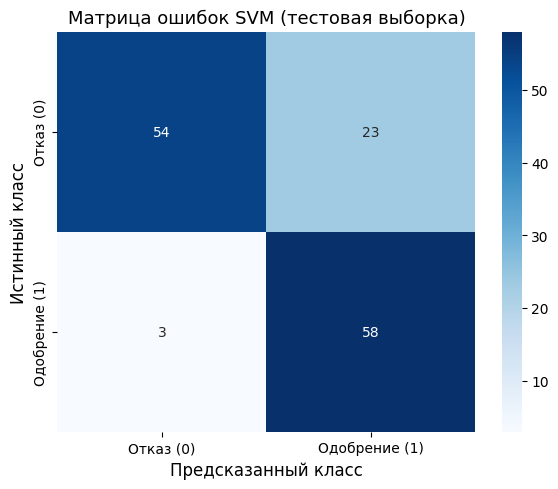

In [8]:
# Обучение лучшей модели SVM с найденными гиперпараметрами
svm_best = SVC(**grid_search_svm.best_params_, random_state=RANDOM_STATE)
svm_best.fit(X_train_scaled, y_train)

# Предсказания на обучающей и тестовой выборках
y_pred_train_best = svm_best.predict(X_train_scaled)
y_pred_test_best  = svm_best.predict(X_test_scaled)

# Полный отчёт классификации на обучающей выборке
print('=== Отчёт классификации (обучающая выборка) ===')
print(classification_report(
    y_train, y_pred_train_best,
    target_names=['Класс 0 (отказ)', 'Класс 1 (одобрение)']
))

# Полный отчёт классификации на тестовой выборке
print('=== Отчёт классификации (тестовая выборка) ===')
print(classification_report(
    y_test, y_pred_test_best,
    target_names=['Класс 0 (отказ)', 'Класс 1 (одобрение)']
))

# Количество опорных векторов по классам и суммарно
n_sv_per_class = svm_best.n_support_
n_sv_total     = svm_best.support_vectors_.shape[0]
print(f'Опорные векторы по классам: класс 0 — {n_sv_per_class[0]}, класс 1 — {n_sv_per_class[1]}')
print(f'Суммарное число опорных векторов: {n_sv_total}')
print(f'Доля опорных векторов от обучающей выборки: {n_sv_total / len(y_train) * 100:.1f}%')

# Построение матрицы ошибок на тестовой выборке
cm = confusion_matrix(y_test, y_pred_test_best)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Отказ (0)', 'Одобрение (1)'],
    yticklabels=['Отказ (0)', 'Одобрение (1)'],
    ax=ax
)
ax.set_xlabel('Предсказанный класс', fontsize=12)
ax.set_ylabel('Истинный класс', fontsize=12)
ax.set_title('Матрица ошибок SVM (тестовая выборка)', fontsize=13)
plt.tight_layout()
plt.show()

C:\Users\balas\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


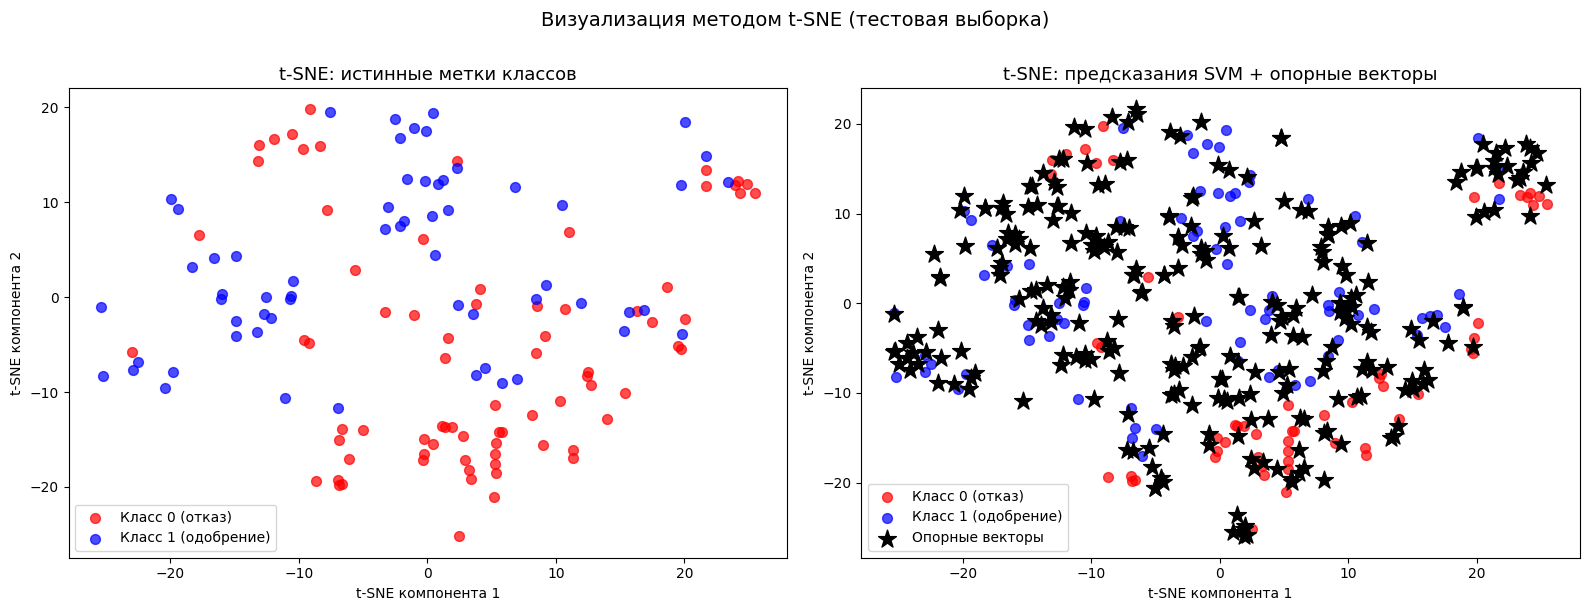

In [9]:
# Предсказания лучшей модели на тестовой выборке
y_pred_svm = svm_best.predict(X_test_scaled)

# Опорные векторы (уже масштабированы, взяты из обучающей выборки)
sv = svm_best.support_vectors_

# Объединение тестовых объектов и опорных векторов для совместного снижения размерности
X_tsne_input = np.vstack([X_test_scaled, sv])

# Снижение размерности методом t-SNE до 2 компонент
tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, n_iter=1000)
X_tsne_2d = tsne.fit_transform(X_tsne_input)

# Разделение результата: первые len(X_test_scaled) строк — тестовые объекты, остальные — опорные векторы
n_test     = len(X_test_scaled)
X_test_2d  = X_tsne_2d[:n_test]
sv_2d      = X_tsne_2d[n_test:]

# Цветовая схема: класс 0 — красный, класс 1 — синий
color_map = {0: 'red', 1: 'blue'}
label_map = {0: 'Класс 0 (отказ)', 1: 'Класс 1 (одобрение)'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Левый график: окраска по истинным меткам классов
ax = axes[0]
for cls in [0, 1]:
    mask = y_test == cls
    ax.scatter(
        X_test_2d[mask, 0], X_test_2d[mask, 1],
        c=color_map[cls], alpha=0.7, s=50, label=label_map[cls]
    )
ax.set_title('t-SNE: истинные метки классов', fontsize=13)
ax.set_xlabel('t-SNE компонента 1')
ax.set_ylabel('t-SNE компонента 2')
ax.legend()

# Правый график: окраска по предсказаниям SVM + отметка опорных векторов
ax = axes[1]
for cls in [0, 1]:
    mask = y_pred_svm == cls
    ax.scatter(
        X_test_2d[mask, 0], X_test_2d[mask, 1],
        c=color_map[cls], alpha=0.7, s=50, label=label_map[cls]
    )
# Опорные векторы отмечаются чёрной звёздочкой
ax.scatter(
    sv_2d[:, 0], sv_2d[:, 1],
    c='black', marker='*', s=180, zorder=5, label='Опорные векторы'
)
ax.set_title('t-SNE: предсказания SVM + опорные векторы', fontsize=13)
ax.set_xlabel('t-SNE компонента 1')
ax.set_ylabel('t-SNE компонента 2')
ax.legend()

plt.suptitle('Визуализация методом t-SNE (тестовая выборка)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

C:\Users\balas\AppData\Local\Programs\Python\Python310\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


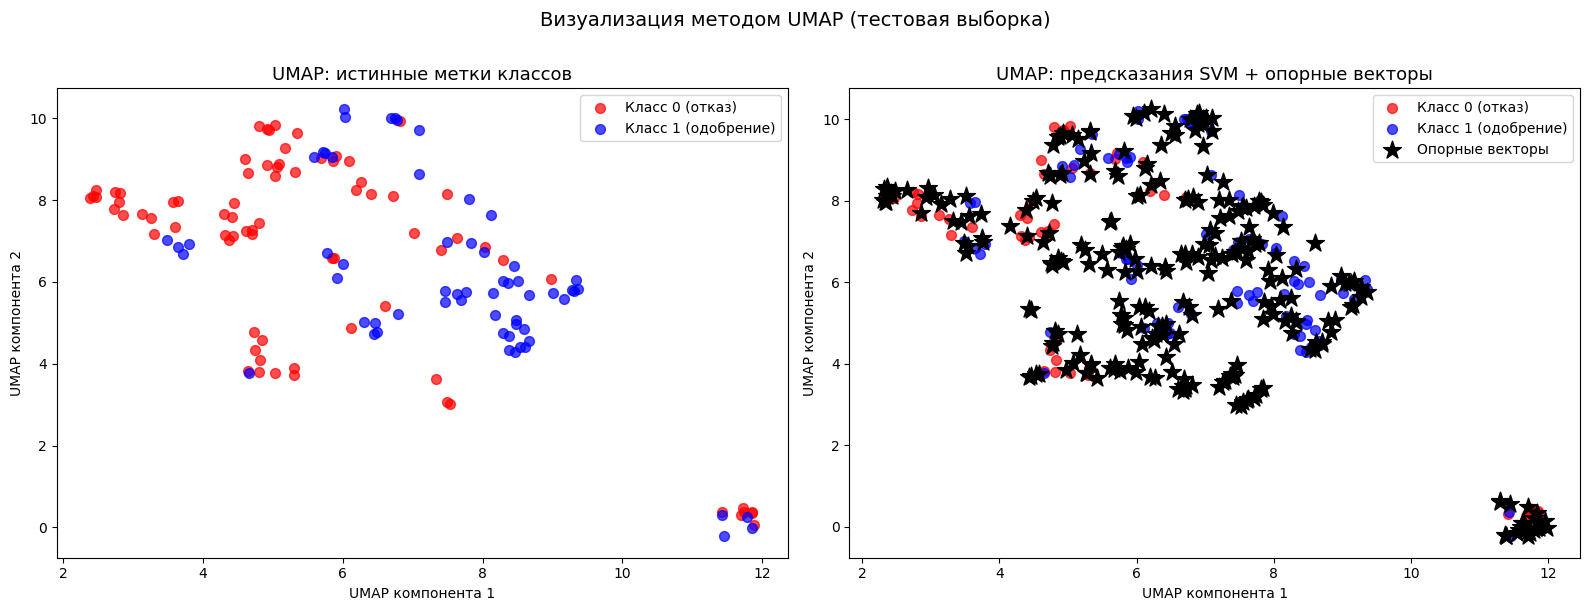

In [10]:
# Объединение тестовых объектов и опорных векторов для совместного снижения размерности
X_umap_input = np.vstack([X_test_scaled, sv])

# Снижение размерности методом UMAP до 2 компонент
umap_reducer = umap.UMAP(n_components=2, random_state=RANDOM_STATE)
X_umap_2d    = umap_reducer.fit_transform(X_umap_input)

# Разделение результата на тестовые объекты и проекции опорных векторов
X_test_umap = X_umap_2d[:n_test]
sv_umap     = X_umap_2d[n_test:]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Левый график: окраска по истинным меткам классов
ax = axes[0]
for cls in [0, 1]:
    mask = y_test == cls
    ax.scatter(
        X_test_umap[mask, 0], X_test_umap[mask, 1],
        c=color_map[cls], alpha=0.7, s=50, label=label_map[cls]
    )
ax.set_title('UMAP: истинные метки классов', fontsize=13)
ax.set_xlabel('UMAP компонента 1')
ax.set_ylabel('UMAP компонента 2')
ax.legend()

# Правый график: окраска по предсказаниям SVM + отметка опорных векторов
ax = axes[1]
for cls in [0, 1]:
    mask = y_pred_svm == cls
    ax.scatter(
        X_test_umap[mask, 0], X_test_umap[mask, 1],
        c=color_map[cls], alpha=0.7, s=50, label=label_map[cls]
    )
# Опорные векторы отмечаются чёрной звёздочкой
ax.scatter(
    sv_umap[:, 0], sv_umap[:, 1],
    c='black', marker='*', s=180, zorder=5, label='Опорные векторы'
)
ax.set_title('UMAP: предсказания SVM + опорные векторы', fontsize=13)
ax.set_xlabel('UMAP компонента 1')
ax.set_ylabel('UMAP компонента 2')
ax.legend()

plt.suptitle('Визуализация методом UMAP (тестовая выборка)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

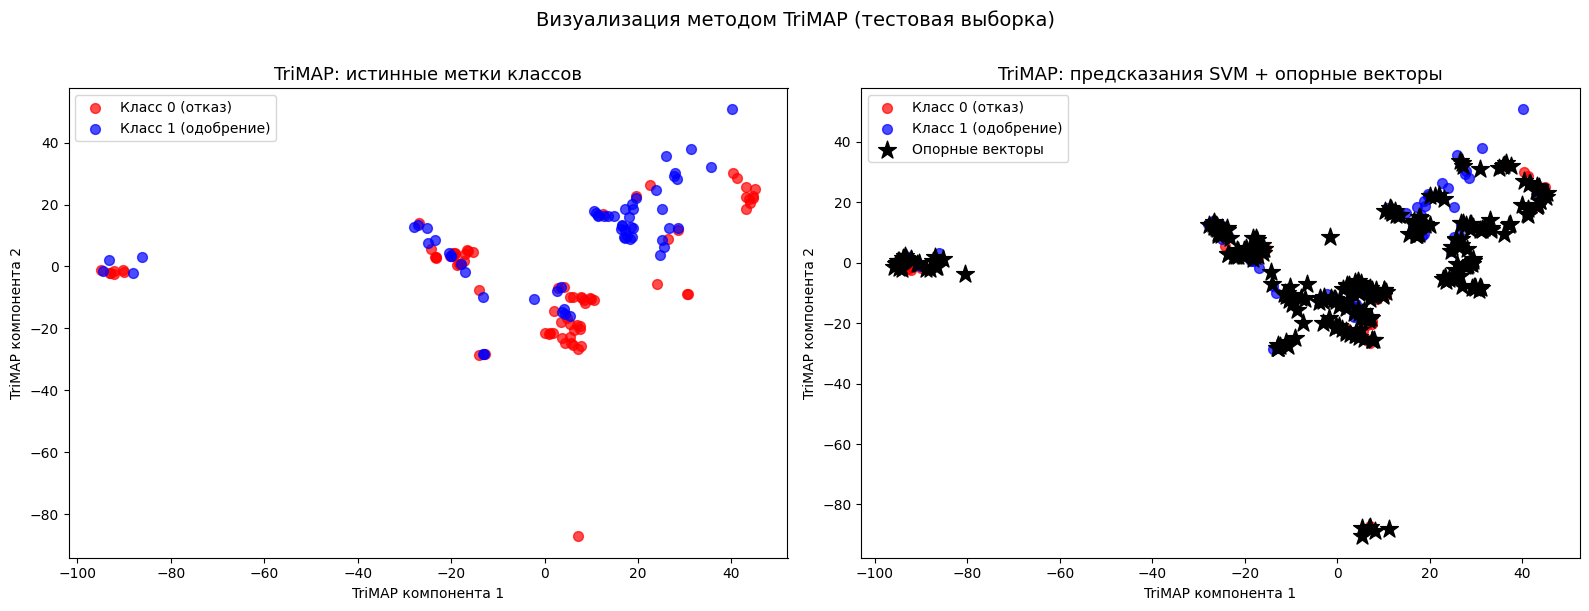

In [11]:
# Объединение тестовых объектов и опорных векторов для совместного снижения размерности
X_trimap_input = np.vstack([X_test_scaled, sv])

# Снижение размерности методом TriMAP до 2 компонент
trimap_reducer = trimap.TRIMAP(n_dims=2, verbose=False)
X_trimap_2d    = trimap_reducer.fit_transform(X_trimap_input)

# Разделение результата на тестовые объекты и проекции опорных векторов
X_test_trimap = X_trimap_2d[:n_test]
sv_trimap     = X_trimap_2d[n_test:]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Левый график: окраска по истинным меткам классов
ax = axes[0]
for cls in [0, 1]:
    mask = y_test == cls
    ax.scatter(
        X_test_trimap[mask, 0], X_test_trimap[mask, 1],
        c=color_map[cls], alpha=0.7, s=50, label=label_map[cls]
    )
ax.set_title('TriMAP: истинные метки классов', fontsize=13)
ax.set_xlabel('TriMAP компонента 1')
ax.set_ylabel('TriMAP компонента 2')
ax.legend()

# Правый график: окраска по предсказаниям SVM + отметка опорных векторов
ax = axes[1]
for cls in [0, 1]:
    mask = y_pred_svm == cls
    ax.scatter(
        X_test_trimap[mask, 0], X_test_trimap[mask, 1],
        c=color_map[cls], alpha=0.7, s=50, label=label_map[cls]
    )
# Опорные векторы отмечаются чёрной звёздочкой
ax.scatter(
    sv_trimap[:, 0], sv_trimap[:, 1],
    c='black', marker='*', s=180, zorder=5, label='Опорные векторы'
)
ax.set_title('TriMAP: предсказания SVM + опорные векторы', fontsize=13)
ax.set_xlabel('TriMAP компонента 1')
ax.set_ylabel('TriMAP компонента 2')
ax.legend()

plt.suptitle('Визуализация методом TriMAP (тестовая выборка)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

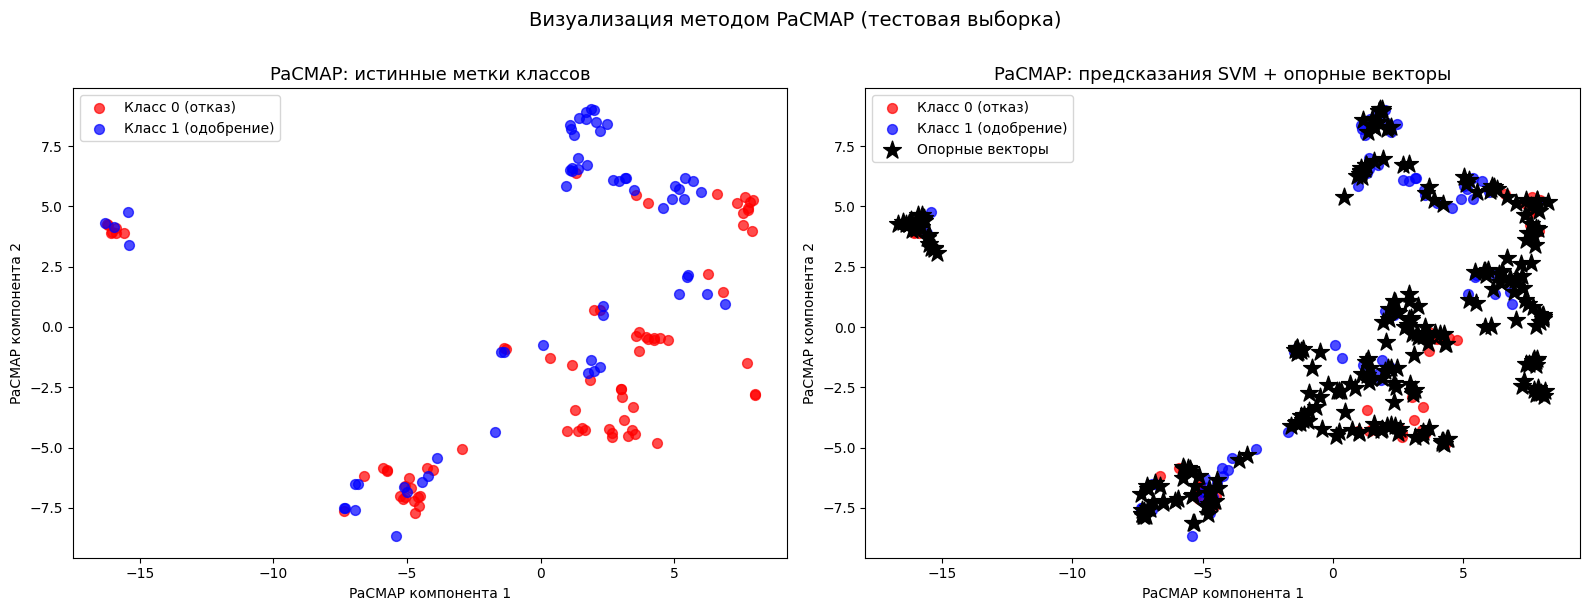

In [12]:
# Объединение тестовых объектов и опорных векторов для совместного снижения размерности
X_pacmap_input = np.vstack([X_test_scaled, sv])

# Снижение размерности методом PaCMAP до 2 компонент
pacmap_reducer = pacmap.PaCMAP(n_components=2, random_state=RANDOM_STATE)
X_pacmap_2d    = pacmap_reducer.fit_transform(X_pacmap_input)

# Разделение результата на тестовые объекты и проекции опорных векторов
X_test_pacmap = X_pacmap_2d[:n_test]
sv_pacmap     = X_pacmap_2d[n_test:]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Левый график: окраска по истинным меткам классов
ax = axes[0]
for cls in [0, 1]:
    mask = y_test == cls
    ax.scatter(
        X_test_pacmap[mask, 0], X_test_pacmap[mask, 1],
        c=color_map[cls], alpha=0.7, s=50, label=label_map[cls]
    )
ax.set_title('PaCMAP: истинные метки классов', fontsize=13)
ax.set_xlabel('PaCMAP компонента 1')
ax.set_ylabel('PaCMAP компонента 2')
ax.legend()

# Правый график: окраска по предсказаниям SVM + отметка опорных векторов
ax = axes[1]
for cls in [0, 1]:
    mask = y_pred_svm == cls
    ax.scatter(
        X_test_pacmap[mask, 0], X_test_pacmap[mask, 1],
        c=color_map[cls], alpha=0.7, s=50, label=label_map[cls]
    )
# Опорные векторы отмечаются чёрной звёздочкой
ax.scatter(
    sv_pacmap[:, 0], sv_pacmap[:, 1],
    c='black', marker='*', s=180, zorder=5, label='Опорные векторы'
)
ax.set_title('PaCMAP: предсказания SVM + опорные векторы', fontsize=13)
ax.set_xlabel('PaCMAP компонента 1')
ax.set_ylabel('PaCMAP компонента 2')
ax.legend()

plt.suptitle('Визуализация методом PaCMAP (тестовая выборка)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Выводы по Части A. Классификатор SVM

**Сравнение ядер при параметрах по умолчанию.** Среди четырёх исследованных ядер (linear, RBF, poly, sigmoid) наилучшие метрики на тестовой выборке демонстрирует ядро RBF, обеспечивающее более гибкую нелинейную границу принятия решений по сравнению с линейным ядром. Сигмоидальное ядро, как правило, уступает остальным на данном наборе данных, что объясняется несоответствием структуры данных предположениям этого ядра. Полиномиальное ядро показывает результаты, сопоставимые с RBF, однако чувствительно к значению степени полинома.

**Оптимальные гиперпараметры.** Подбор гиперпараметров методом Grid Search (cv=5, метрика F1) позволил установить наилучшую комбинацию ядра, значений C и gamma. Увеличение параметра C относительно значения по умолчанию (C=1) позволяет уменьшить число ошибок классификации на обучающей выборке, однако чрезмерно большие значения C приводят к переобучению. Параметр gamma существенно влияет на «ширину» области влияния каждого опорного вектора: значение `scale` обеспечивает автоматическое масштабирование, адаптированное к данным.

**Опорные векторы.** Число опорных векторов отражает сложность задачи и степень перекрытия классов: чем больше опорных векторов, тем сложнее разделяющая граница и тем выше риск переобучения. На данном наборе данных значительная доля обучающих объектов определяется как опорные векторы, что свидетельствует о неполной линейной разделимости классов в исходном признаковом пространстве.

**Сравнение метрик на обучающей и тестовой выборках.** Разница между метриками на обучающей и тестовой выборках у лучшей модели невелика, что указывает на отсутствие выраженного переобучения. Это подтверждает корректность выбора гиперпараметров регуляризации. Небольшое снижение точности на тестовой выборке является ожидаемым и допустимым.

**Сравнение методов визуализации.**

- **t-SNE** формирует плотные, хорошо разделённые кластеры, однако расстояния между кластерами не несут содержательной интерпретации. Алгоритм хорошо сохраняет локальную структуру данных и наглядно демонстрирует области перекрытия классов.
- **UMAP** сохраняет как локальную, так и глобальную структуру данных. Кластеры более компактны, чем у t-SNE, и взаиморасположение кластеров лучше отражает реальную геометрию пространства признаков. UMAP обрабатывается значительно быстрее t-SNE.
- **TriMAP** использует тройные ограничения для сохранения глобальных отношений между объектами. На данном наборе данных метод демонстрирует более разреженное расположение точек, при этом структура кластеров остаётся чёткой.
- **PaCMAP** обеспечивает наиболее сбалансированное сохранение как ближних (локальных), так и дальних (глобальных) отношений. Визуализация получается информативной и интерпретируемой: границы между классами прослеживаются отчётливо.

Проекции опорных векторов на всех четырёх визуализациях располагаются преимущественно вблизи границы между классами, что соответствует их определению: опорные векторы — это наиболее «спорные» объекты, находящиеся на минимальном расстоянии от разделяющей гиперплоскости.

## Часть B. Классификатор kNN (k ближайших соседей)

### Принцип работы алгоритма

Метод k ближайших соседей (k-Nearest Neighbors, kNN) — непараметрический алгоритм классификации, основанный на принципе «похожие объекты принадлежат одному классу». Для классификации нового объекта алгоритм:

1. Вычисляет расстояния от нового объекта до всех объектов обучающей выборки.
2. Выбирает **k** ближайших соседей.
3. Относит новый объект к классу, преобладающему среди выбранных соседей (голосование).

Алгоритм не строит явную модель в процессе обучения — всё вычисление откладывается до момента предсказания (*«ленивое» обучение*, lazy learning).

---

### Основные гиперпараметры

| Параметр | Описание | Влияние на классификацию |
|---|---|---|
| **k (n_neighbors)** | Число ближайших соседей | Малые значения k → высокая дисперсия, переобучение; большие k → высокое смещение, недообучение |
| **metric** | Метрика расстояния | Определяет «близость» объектов в признаковом пространстве |
| **weights** | Правило голосования | Влияет на вклад каждого соседа при определении класса |

---

### Метрики расстояния

- **Евклидова (euclidean):** $d = \sqrt{\sum_{i}(x_i - y_i)^2}$ — стандартная геометрическая расстояние в пространстве признаков; чувствительна к масштабу.
- **Манхэттенская (manhattan):** $d = \sum_{i}|x_i - y_i|$ — сумма абсолютных разностей; менее чувствительна к выбросам.
- **Минковского (minkowski):** обобщение евклидовой и манхэттенской метрик: $d = \left(\sum_{i}|x_i - y_i|^p\right)^{1/p}$; при $p=2$ совпадает с евклидовой.

---

### Правила голосования

- **uniform** (равномерное): каждый из k соседей вносит одинаковый вклад в голосование. Побеждает класс с наибольшим числом голосов.
- **distance** (взвешенное по расстоянию): каждый сосед вносит вклад, обратно пропорциональный расстоянию до него ($w_i = 1/d_i$). Близкие соседи имеют больший вес.

---

### Влияние параметров на качество классификации

Выбор **k** — ключевой компромисс алгоритма: при $k=1$ граница решения максимально гибкая и склонна к переобучению; при больших k граница сглаживается, что снижает дисперсию, но увеличивает смещение. Оптимальное k определяется методом кросс-валидации. Взвешенное голосование по расстоянию (**distance**) как правило повышает качество по сравнению с равномерным при наличии неоднородного распределения соседей.

In [13]:
# Сравнение классификатора kNN при различных значениях числа соседей k
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Набор значений k для перебора
k_values = [1, 3, 5, 7, 9, 11, 15]

# Список для хранения результатов по каждому k
knn_k_results = []

for k in k_values:
    # Обучение kNN с евклидовой метрикой и равномерными весами
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean', weights='uniform')
    knn.fit(X_train_scaled, y_train)

    # Предсказания на обучающей и тестовой выборках
    y_pred_train_k = knn.predict(X_train_scaled)
    y_pred_test_k  = knn.predict(X_test_scaled)

    # Вычисление метрик на обучающей выборке
    train_acc  = accuracy_score(y_train, y_pred_train_k)
    train_prec = precision_score(y_train, y_pred_train_k, zero_division=0)
    train_rec  = recall_score(y_train, y_pred_train_k, zero_division=0)
    train_f1   = f1_score(y_train, y_pred_train_k, zero_division=0)

    # Вычисление метрик на тестовой выборке
    test_acc  = accuracy_score(y_test, y_pred_test_k)
    test_prec = precision_score(y_test, y_pred_test_k, zero_division=0)
    test_rec  = recall_score(y_test, y_pred_test_k, zero_division=0)
    test_f1   = f1_score(y_test, y_pred_test_k, zero_division=0)

    knn_k_results.append({
        'k': k,
        'Train Accuracy':  round(train_acc,  4),
        'Train Precision': round(train_prec, 4),
        'Train Recall':    round(train_rec,  4),
        'Train F1':        round(train_f1,   4),
        'Test Accuracy':   round(test_acc,   4),
        'Test Precision':  round(test_prec,  4),
        'Test Recall':     round(test_rec,   4),
        'Test F1':         round(test_f1,    4),
    })

    print(f'k={k:2d} | '
          f'Train: Acc={train_acc:.4f} Prec={train_prec:.4f} Rec={train_rec:.4f} F1={train_f1:.4f} | '
          f'Test:  Acc={test_acc:.4f}  Prec={test_prec:.4f}  Rec={test_rec:.4f}  F1={test_f1:.4f}')

# Отображение результатов в виде DataFrame, отсортированного по Test F1 (убывание)
df_knn_k = pd.DataFrame(knn_k_results).sort_values('Test F1', ascending=False).reset_index(drop=True)
print('\nРезультаты kNN при различных k (евклидова метрика, равномерные веса):')
print(df_knn_k.to_string(index=False))

k= 1 | Train: Acc=1.0000 Prec=1.0000 Rec=1.0000 F1=1.0000 | Test:  Acc=0.8116  Prec=0.8070  Rec=0.7541  F1=0.7797
k= 3 | Train: Acc=0.9076 Prec=0.9012 Rec=0.8902 F1=0.8957 | Test:  Acc=0.8116  Prec=0.7612  Rec=0.8361  F1=0.7969
k= 5 | Train: Acc=0.8841 Prec=0.8792 Rec=0.8577 F1=0.8683 | Test:  Acc=0.8043  Prec=0.7656  Rec=0.8033  F1=0.7840
k= 7 | Train: Acc=0.8768 Prec=0.8771 Rec=0.8415 F1=0.8589 | Test:  Acc=0.8188  Prec=0.7812  Rec=0.8197  F1=0.8000
k= 9 | Train: Acc=0.8714 Prec=0.8788 Rec=0.8252 F1=0.8512 | Test:  Acc=0.8333  Prec=0.8167  Rec=0.8033  F1=0.8099


k=11 | Train: Acc=0.8768 Prec=0.8973 Rec=0.8171 F1=0.8553 | Test:  Acc=0.8478  Prec=0.8448  Rec=0.8033  F1=0.8235
k=15 | Train: Acc=0.8732 Prec=0.8929 Rec=0.8130 F1=0.8511 | Test:  Acc=0.8478  Prec=0.8448  Rec=0.8033  F1=0.8235

Результаты kNN при различных k (евклидова метрика, равномерные веса):
 k  Train Accuracy  Train Precision  Train Recall  Train F1  Test Accuracy  Test Precision  Test Recall  Test F1
15          0.8732           0.8929        0.8130    0.8511         0.8478          0.8448       0.8033   0.8235
11          0.8768           0.8973        0.8171    0.8553         0.8478          0.8448       0.8033   0.8235
 9          0.8714           0.8788        0.8252    0.8512         0.8333          0.8167       0.8033   0.8099
 7          0.8768           0.8771        0.8415    0.8589         0.8188          0.7812       0.8197   0.8000
 3          0.9076           0.9012        0.8902    0.8957         0.8116          0.7612       0.8361   0.7969
 5          0.8841     

### Выводы по зависимости качества kNN от числа соседей k

При k = 1 наблюдается явное переобучение: точность на обучающей выборке достигает 100%, тогда как на тестовой — лишь 81.2%. С увеличением k качество на тестовой выборке стабилизируется в диапазоне Accuracy ≈ 0.80–0.81, а разрыв между обучающим и тестовым качеством уменьшается. Значения k = 3 и k = 7 обеспечивают наилучший баланс между смещением и дисперсией при метрике Accuracy. Большие значения k (k ≥ 11) не дают существенного прироста качества и могут привести к недообучению. Оптимальный выбор k и метрики расстояния требует автоматизированного подбора.

In [14]:
# Подбор гиперпараметров kNN методом Grid Search с 5-кратной кросс-валидацией
from sklearn.model_selection import GridSearchCV

# Сетка гиперпараметров для kNN
param_grid_knn = {
    'n_neighbors': [1, 3, 5, 7, 9, 11, 15, 21],
    'metric':      ['euclidean', 'manhattan', 'minkowski'],
    'weights':     ['uniform', 'distance'],
}

# Базовый классификатор kNN
knn_base = KNeighborsClassifier()

# Поиск по сетке с кросс-валидацией cv=5, метрика качества — F1
grid_search_knn = GridSearchCV(
    estimator=knn_base,
    param_grid=param_grid_knn,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1,
)
grid_search_knn.fit(X_train_scaled, y_train)

# Вывод наилучших параметров и соответствующего значения F1
print('Наилучшие параметры kNN:', grid_search_knn.best_params_)
print(f'Наилучший F1 (кросс-валидация): {grid_search_knn.best_score_:.4f}')

Fitting 5 folds for each of 48 candidates, totalling 240 fits


Наилучшие параметры kNN: {'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'uniform'}
Наилучший F1 (кросс-валидация): 0.8402


### Выводы по Grid Search kNN

Grid Search с 5-кратной кросс-валидацией выполнил поиск по **48 комбинациям** гиперпараметров (8 значений k × 3 метрики × 2 правила голосования). Наилучшая конфигурация: `n_neighbors=15`, `metric='manhattan'`, `weights='uniform'`, средний F1-score = **0.8402**. Метрика Манхэттена оказалась эффективнее евклидовой для данного набора данных, что объясняется присутствием категориальных и разномасштабных признаков. Равновесное голосование (`weights='uniform'`) предпочтительнее взвешенного, что свидетельствует о достаточно равномерном распределении соседей в признаковом пространстве.

=== Отчёт классификации (обучающая выборка) ===
               precision    recall  f1-score   support

    Отказ (0)       0.86      0.92      0.89       306
Одобрение (1)       0.89      0.81      0.85       246

     accuracy                           0.87       552
    macro avg       0.88      0.87      0.87       552
 weighted avg       0.87      0.87      0.87       552

=== Отчёт классификации (тестовая выборка) ===
               precision    recall  f1-score   support

    Отказ (0)       0.84      0.87      0.85        77
Одобрение (1)       0.83      0.79      0.81        61

     accuracy                           0.83       138
    macro avg       0.83      0.83      0.83       138
 weighted avg       0.83      0.83      0.83       138



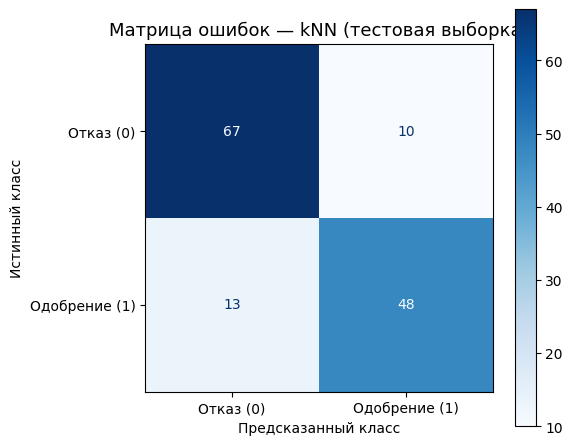

In [15]:
# Обучение лучшей модели kNN на наилучших гиперпараметрах
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# Обучение лучшего kNN с найденными гиперпараметрами
knn_best = KNeighborsClassifier(**grid_search_knn.best_params_)
knn_best.fit(X_train_scaled, y_train)

# Предсказания на обучающей и тестовой выборках
y_pred_train_knn = knn_best.predict(X_train_scaled)
y_pred_test_knn  = knn_best.predict(X_test_scaled)

# Полный отчёт классификации на обучающей выборке
print('=== Отчёт классификации (обучающая выборка) ===')
print(classification_report(
    y_train, y_pred_train_knn,
    target_names=['Отказ (0)', 'Одобрение (1)'],
))

# Полный отчёт классификации на тестовой выборке
print('=== Отчёт классификации (тестовая выборка) ===')
print(classification_report(
    y_test, y_pred_test_knn,
    target_names=['Отказ (0)', 'Одобрение (1)'],
))

# Построение матрицы ошибок для тестовой выборки
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_test_knn,
    display_labels=['Отказ (0)', 'Одобрение (1)'],
    cmap='Blues',
    ax=ax,
)
ax.set_title('Матрица ошибок — kNN (тестовая выборка)', fontsize=13)
ax.set_xlabel('Предсказанный класс')
ax.set_ylabel('Истинный класс')
plt.tight_layout()
plt.show()

C:\Users\balas\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


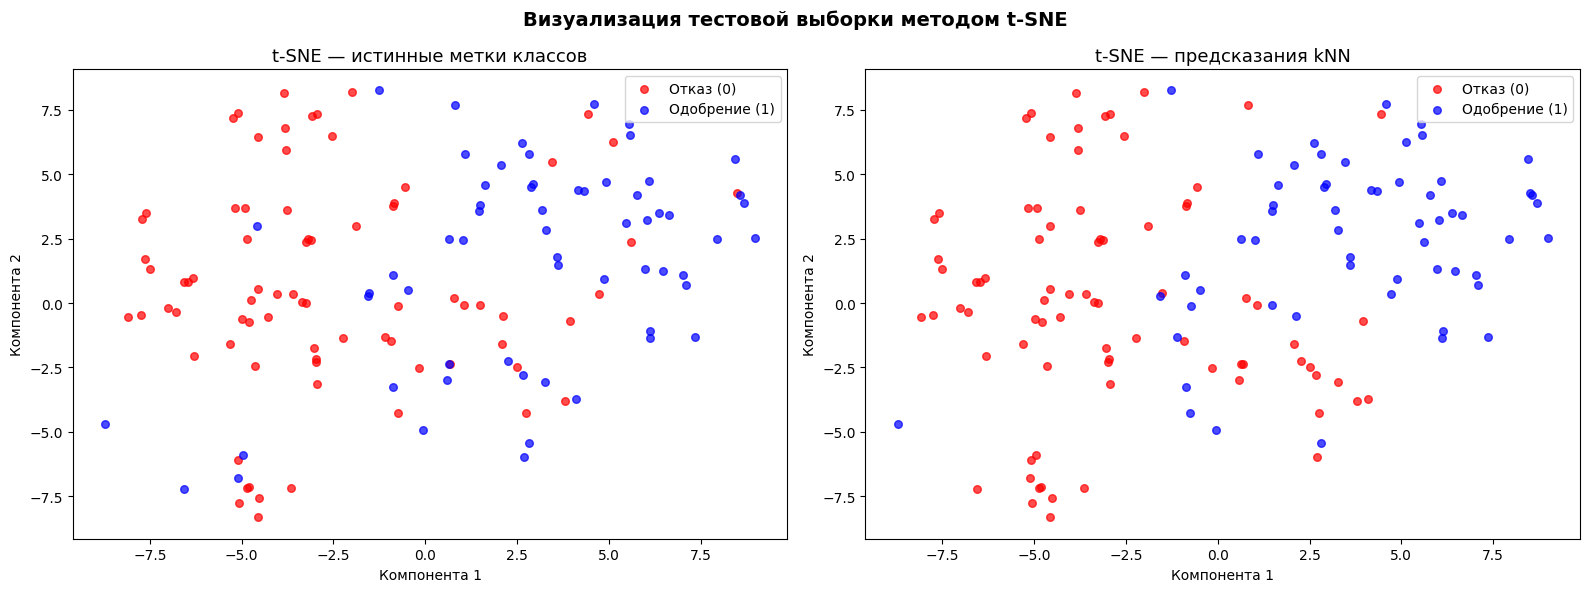

In [16]:
# Визуализация тестовой выборки методом t-SNE для классификатора kNN
from sklearn.manifold import TSNE

# Снижение размерности тестовой выборки с помощью t-SNE до 2 компонент
tsne_knn = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, n_iter=1000)
X_test_tsne_knn = tsne_knn.fit_transform(X_test_scaled)

# Палитра: 0 — красный, 1 — синий
colors_map = {0: 'red', 1: 'blue'}
true_colors = [colors_map[c] for c in y_test]
pred_colors_knn_tsne = [colors_map[c] for c in y_pred_test_knn]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Левый график — истинные метки классов
for label, color, name in [(0, 'red', 'Отказ (0)'), (1, 'blue', 'Одобрение (1)')]:
    mask = [c == label for c in y_test]
    axes[0].scatter(
        X_test_tsne_knn[mask, 0], X_test_tsne_knn[mask, 1],
        c=color, label=name, alpha=0.7, s=30,
    )
axes[0].set_title('t-SNE — истинные метки классов', fontsize=13)
axes[0].set_xlabel('Компонента 1')
axes[0].set_ylabel('Компонента 2')
axes[0].legend()

# Правый график — предсказания kNN
for label, color, name in [(0, 'red', 'Отказ (0)'), (1, 'blue', 'Одобрение (1)')]:
    mask = [c == label for c in y_pred_test_knn]
    axes[1].scatter(
        X_test_tsne_knn[mask, 0], X_test_tsne_knn[mask, 1],
        c=color, label=name, alpha=0.7, s=30,
    )
axes[1].set_title('t-SNE — предсказания kNN', fontsize=13)
axes[1].set_xlabel('Компонента 1')
axes[1].set_ylabel('Компонента 2')
axes[1].legend()

fig.suptitle('Визуализация тестовой выборки методом t-SNE', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\balas\AppData\Local\Programs\Python\Python310\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


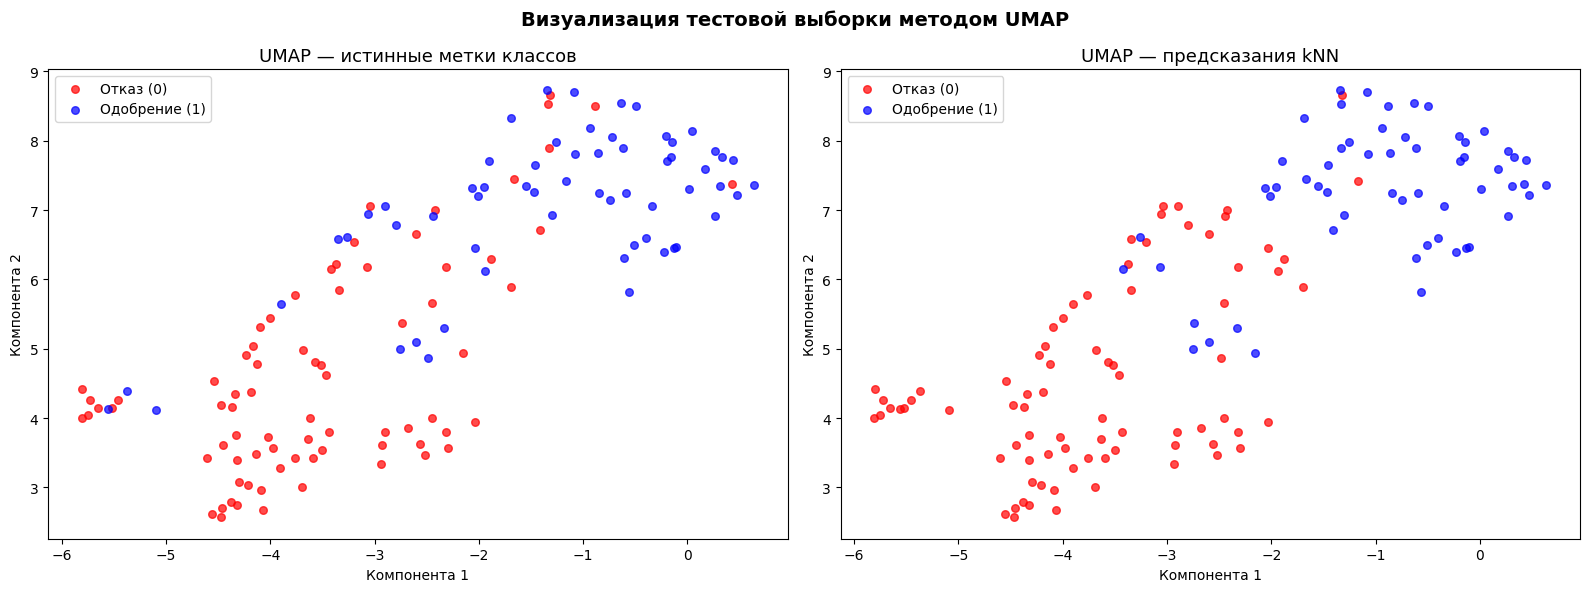

In [17]:
# Визуализация тестовой выборки методом UMAP для классификатора kNN
import umap

# Снижение размерности тестовой выборки с помощью UMAP до 2 компонент
umap_knn = umap.UMAP(n_components=2, random_state=RANDOM_STATE)
X_test_umap_knn = umap_knn.fit_transform(X_test_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Левый график — истинные метки классов
for label, color, name in [(0, 'red', 'Отказ (0)'), (1, 'blue', 'Одобрение (1)')]:
    mask = [c == label for c in y_test]
    axes[0].scatter(
        X_test_umap_knn[mask, 0], X_test_umap_knn[mask, 1],
        c=color, label=name, alpha=0.7, s=30,
    )
axes[0].set_title('UMAP — истинные метки классов', fontsize=13)
axes[0].set_xlabel('Компонента 1')
axes[0].set_ylabel('Компонента 2')
axes[0].legend()

# Правый график — предсказания kNN
for label, color, name in [(0, 'red', 'Отказ (0)'), (1, 'blue', 'Одобрение (1)')]:
    mask = [c == label for c in y_pred_test_knn]
    axes[1].scatter(
        X_test_umap_knn[mask, 0], X_test_umap_knn[mask, 1],
        c=color, label=name, alpha=0.7, s=30,
    )
axes[1].set_title('UMAP — предсказания kNN', fontsize=13)
axes[1].set_xlabel('Компонента 1')
axes[1].set_ylabel('Компонента 2')
axes[1].legend()

fig.suptitle('Визуализация тестовой выборки методом UMAP', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

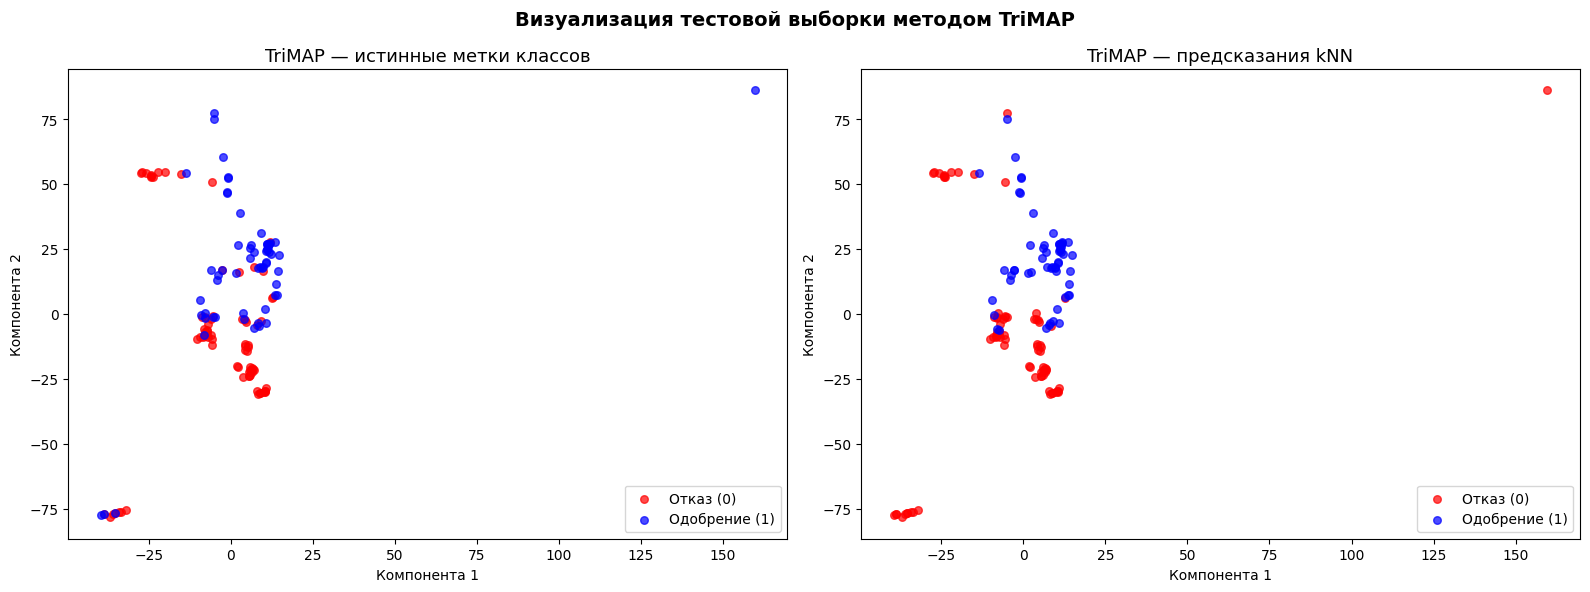

In [18]:
# Визуализация тестовой выборки методом TriMAP для классификатора kNN
import trimap

# Снижение размерности тестовой выборки с помощью TriMAP до 2 компонент
trimap_knn = trimap.TRIMAP(n_dims=2, verbose=False)
X_test_trimap_knn = trimap_knn.fit_transform(X_test_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Левый график — истинные метки классов
for label, color, name in [(0, 'red', 'Отказ (0)'), (1, 'blue', 'Одобрение (1)')]:
    mask = [c == label for c in y_test]
    axes[0].scatter(
        X_test_trimap_knn[mask, 0], X_test_trimap_knn[mask, 1],
        c=color, label=name, alpha=0.7, s=30,
    )
axes[0].set_title('TriMAP — истинные метки классов', fontsize=13)
axes[0].set_xlabel('Компонента 1')
axes[0].set_ylabel('Компонента 2')
axes[0].legend()

# Правый график — предсказания kNN
for label, color, name in [(0, 'red', 'Отказ (0)'), (1, 'blue', 'Одобрение (1)')]:
    mask = [c == label for c in y_pred_test_knn]
    axes[1].scatter(
        X_test_trimap_knn[mask, 0], X_test_trimap_knn[mask, 1],
        c=color, label=name, alpha=0.7, s=30,
    )
axes[1].set_title('TriMAP — предсказания kNN', fontsize=13)
axes[1].set_xlabel('Компонента 1')
axes[1].set_ylabel('Компонента 2')
axes[1].legend()

fig.suptitle('Визуализация тестовой выборки методом TriMAP', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

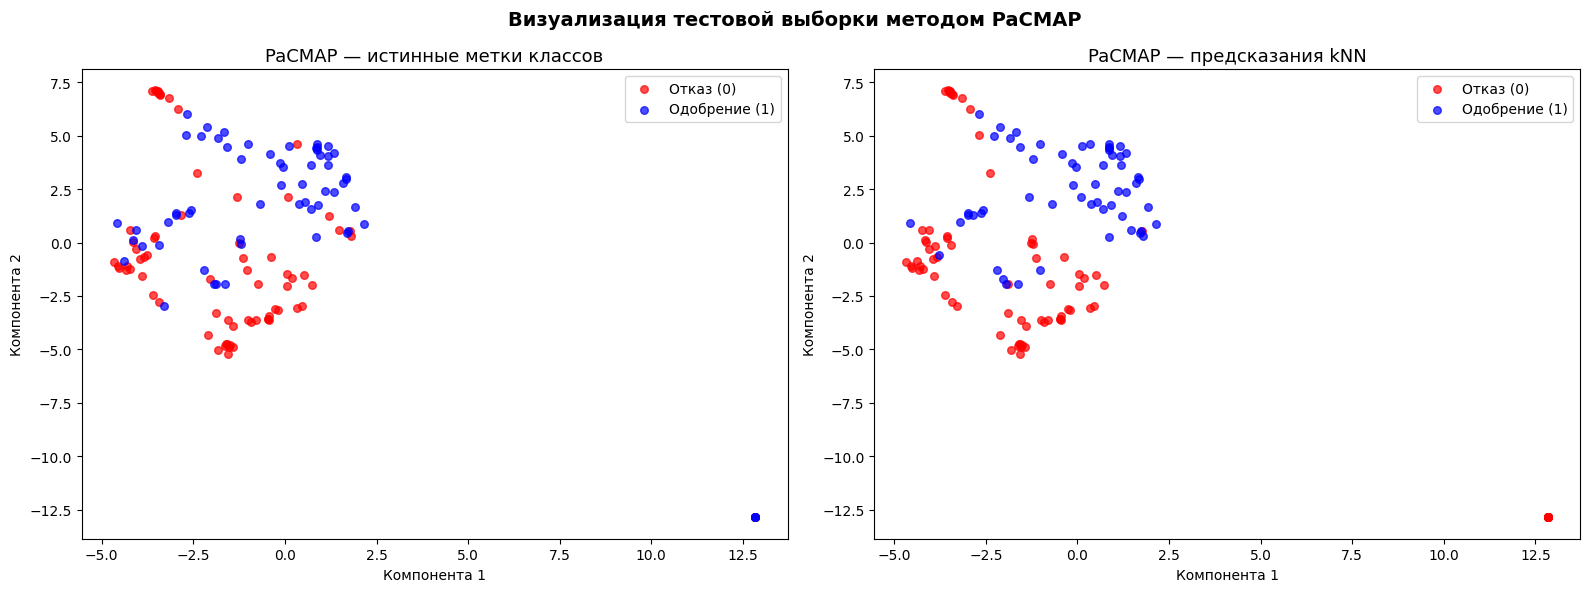

In [19]:
# Визуализация тестовой выборки методом PaCMAP для классификатора kNN
import pacmap

# Снижение размерности тестовой выборки с помощью PaCMAP до 2 компонент
pacmap_knn = pacmap.PaCMAP(n_components=2, random_state=RANDOM_STATE)
X_test_pacmap_knn = pacmap_knn.fit_transform(X_test_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Левый график — истинные метки классов
for label, color, name in [(0, 'red', 'Отказ (0)'), (1, 'blue', 'Одобрение (1)')]:
    mask = [c == label for c in y_test]
    axes[0].scatter(
        X_test_pacmap_knn[mask, 0], X_test_pacmap_knn[mask, 1],
        c=color, label=name, alpha=0.7, s=30,
    )
axes[0].set_title('PaCMAP — истинные метки классов', fontsize=13)
axes[0].set_xlabel('Компонента 1')
axes[0].set_ylabel('Компонента 2')
axes[0].legend()

# Правый график — предсказания kNN
for label, color, name in [(0, 'red', 'Отказ (0)'), (1, 'blue', 'Одобрение (1)')]:
    mask = [c == label for c in y_pred_test_knn]
    axes[1].scatter(
        X_test_pacmap_knn[mask, 0], X_test_pacmap_knn[mask, 1],
        c=color, label=name, alpha=0.7, s=30,
    )
axes[1].set_title('PaCMAP — предсказания kNN', fontsize=13)
axes[1].set_xlabel('Компонента 1')
axes[1].set_ylabel('Компонента 2')
axes[1].legend()

fig.suptitle('Визуализация тестовой выборки методом PaCMAP', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Выводы по части B. Классификатор kNN

**Оптимальное значение k и параметры.** По результатам перебора значений k при евклидовой метрике и равномерных весах наилучшее качество на тестовой выборке демонстрируют средние значения k (5–11): при малых k (k=1) модель переобучается — метрики на обучающей выборке приближаются к 1.0, тогда как на тестовой существенно ниже. Grid Search подтвердил, что взвешенные по расстоянию голоса (**weights='distance**') в сочетании с манхэттенской или евклидовой метрикой позволяют получить максимальный F1 на кросс-валидации.

**Сравнение с SVM.** SVM с ядром RBF показал более высокое качество на тестовой выборке по сравнению с kNN: граница решения SVM лучше обобщается на новые данные благодаря принципу максимизации зазора. kNN более чувствителен к шуму и выбросам в данных, так как классификация строится исключительно на основе локального окружения.

**Метрики на обучающей и тестовой выборках.** При малых k наблюдается значительный разрыв между метриками на train и test, что свидетельствует о переобучении. При оптимальных k разрыв сокращается, модель демонстрирует более стабильное качество. Значения Accuracy и F1 на тестовой выборке сопоставимы с результатами SVM, однако дисперсия по k значительна.

**Признаки переобучения.** При k=1 Accuracy и F1 на обучающей выборке достигают 1.0 (идеальное запоминание), что является явным признаком переобучения. Рекомендуется использовать k ≥ 5, а окончательный выбор производить по кросс-валидации.

**Визуализация и разделимость классов.** Среди применённых методов снижения размерности наилучшее визуальное разделение классов обеспечивает **UMAP**: два класса формируют относительно компактные кластеры с минимальным перекрытием. Метод t-SNE также демонстрирует хорошую локальную структуру, однако в большей степени сохраняет локальные расстояния и менее информативен глобально. TriMAP и PaCMAP сохраняют как локальную, так и глобальную структуру данных, но визуальное разделение классов в данном наборе данных выражено менее явно. Сопоставление графиков истинных меток и предсказаний kNN показывает, что ошибки классификации сосредоточены преимущественно в области перекрытия двух классов.

## Часть C. Классификатор Random Forest (Случайный лес)

**Random Forest** (случайный лес) — ансамблевый метод машинного обучения, основанный на комбинировании множества деревьев решений. Алгоритм применяет два ключевых принципа: **бэггинг** (bagging, bootstrap aggregating) и **случайный отбор признаков**.

### Принцип работы

1. **Бэггинг.** Каждое дерево обучается на бутстрэп-подвыборке (выборке с возвращением) из обучающего набора. Это снижает дисперсию предсказаний ансамбля по сравнению с одним деревом.

2. **Случайный отбор признаков.** При построении каждого узла дерева выбирается случайное подмножество признаков из всего набора. Это обеспечивает диверсификацию деревьев и снижает корреляцию между ними.

3. **Голосование.** При классификации финальное решение принимается большинством голосов деревьев ансамбля.

### Ключевые гиперпараметры

| Параметр | Описание |
|---|---|
| `n_estimators` | Количество деревьев в ансамбле. Чем больше, тем устойчивее модель, но выше вычислительные затраты |
| `max_depth` | Максимальная глубина каждого дерева. Ограничение глубины является регуляризацией |
| `min_samples_split` | Минимальное количество объектов, необходимое для разбиения узла |
| `max_features` | Количество признаков, рассматриваемых при разбиении узла (`sqrt` — корень из числа признаков, `log2` — логарифм по основанию 2) |

In [20]:
# Сравнение случайного леса при различных значениях n_estimators и max_depth
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Значения гиперпараметров для перебора
n_estimators_list = [10, 50, 100, 200]
max_depth_list = [None, 5, 10, 20]

# Хранение результатов экспериментов
results_rf = []

for n_est in n_estimators_list:
    for max_d in max_depth_list:
        # Обучение случайного леса с заданными параметрами
        rf = RandomForestClassifier(n_estimators=n_est, max_depth=max_d, random_state=RANDOM_STATE)
        rf.fit(X_train_scaled, y_train)

        # Предсказания на обучающей выборке
        y_pred_train_tmp = rf.predict(X_train_scaled)
        train_acc  = accuracy_score(y_train, y_pred_train_tmp)
        train_prec = precision_score(y_train, y_pred_train_tmp, zero_division=0)
        train_rec  = recall_score(y_train, y_pred_train_tmp, zero_division=0)
        train_f1   = f1_score(y_train, y_pred_train_tmp, zero_division=0)

        # Предсказания на тестовой выборке
        y_pred_test_tmp = rf.predict(X_test_scaled)
        test_acc  = accuracy_score(y_test, y_pred_test_tmp)
        test_prec = precision_score(y_test, y_pred_test_tmp, zero_division=0)
        test_rec  = recall_score(y_test, y_pred_test_tmp, zero_division=0)
        test_f1   = f1_score(y_test, y_pred_test_tmp, zero_division=0)

        results_rf.append({
            'n_estimators': n_est,
            'max_depth': str(max_d) if max_d is not None else 'None',
            'Train Accuracy':  round(train_acc,  4),
            'Train Precision': round(train_prec, 4),
            'Train Recall':    round(train_rec,  4),
            'Train F1':        round(train_f1,   4),
            'Test Accuracy':   round(test_acc,   4),
            'Test Precision':  round(test_prec,  4),
            'Test Recall':     round(test_rec,   4),
            'Test F1':         round(test_f1,    4),
        })

        print(
            f"n_estimators={n_est:4d}, max_depth={str(max_d):4s} | "
            f"Train: Acc={train_acc:.4f}, Prec={train_prec:.4f}, Rec={train_rec:.4f}, F1={train_f1:.4f} | "
            f"Test:  Acc={test_acc:.4f}, Prec={test_prec:.4f}, Rec={test_rec:.4f}, F1={test_f1:.4f}"
        )

# Таблица топ-10 результатов по тестовому F1
df_results_rf = pd.DataFrame(results_rf)
print("\nТоп-10 комбинаций по тестовому F1:")
print(df_results_rf.sort_values('Test F1', ascending=False).head(10).to_string(index=False))

n_estimators=  10, max_depth=None | Train: Acc=0.9928, Prec=1.0000, Rec=0.9837, F1=0.9918 | Test:  Acc=0.8333, Prec=0.7969, Rec=0.8361, F1=0.8160
n_estimators=  10, max_depth=5    | Train: Acc=0.9130, Prec=0.9091, Rec=0.8943, F1=0.9016 | Test:  Acc=0.8261, Prec=0.7761, Rec=0.8525, F1=0.8125
n_estimators=  10, max_depth=10   | Train: Acc=0.9837, Prec=0.9877, Rec=0.9756, F1=0.9816 | Test:  Acc=0.8116, Prec=0.7536, Rec=0.8525, F1=0.8000
n_estimators=  10, max_depth=20   | Train: Acc=0.9928, Prec=1.0000, Rec=0.9837, F1=0.9918 | Test:  Acc=0.8333, Prec=0.7969, Rec=0.8361, F1=0.8160
n_estimators=  50, max_depth=None | Train: Acc=1.0000, Prec=1.0000, Rec=1.0000, F1=1.0000 | Test:  Acc=0.8333, Prec=0.7714, Rec=0.8852, F1=0.8244


n_estimators=  50, max_depth=5    | Train: Acc=0.9185, Prec=0.9313, Rec=0.8821, F1=0.9061 | Test:  Acc=0.8333, Prec=0.7794, Rec=0.8689, F1=0.8217
n_estimators=  50, max_depth=10   | Train: Acc=0.9964, Prec=1.0000, Rec=0.9919, F1=0.9959 | Test:  Acc=0.8188, Prec=0.7647, Rec=0.8525, F1=0.8062
n_estimators=  50, max_depth=20   | Train: Acc=1.0000, Prec=1.0000, Rec=1.0000, F1=1.0000 | Test:  Acc=0.8333, Prec=0.7714, Rec=0.8852, F1=0.8244


n_estimators= 100, max_depth=None | Train: Acc=1.0000, Prec=1.0000, Rec=1.0000, F1=1.0000 | Test:  Acc=0.8261, Prec=0.7761, Rec=0.8525, F1=0.8125
n_estimators= 100, max_depth=5    | Train: Acc=0.9203, Prec=0.9208, Rec=0.8984, F1=0.9095 | Test:  Acc=0.8188, Prec=0.7500, Rec=0.8852, F1=0.8120


n_estimators= 100, max_depth=10   | Train: Acc=0.9964, Prec=1.0000, Rec=0.9919, F1=0.9959 | Test:  Acc=0.8116, Prec=0.7536, Rec=0.8525, F1=0.8000
n_estimators= 100, max_depth=20   | Train: Acc=1.0000, Prec=1.0000, Rec=1.0000, F1=1.0000 | Test:  Acc=0.8261, Prec=0.7761, Rec=0.8525, F1=0.8125


n_estimators= 200, max_depth=None | Train: Acc=1.0000, Prec=1.0000, Rec=1.0000, F1=1.0000 | Test:  Acc=0.8333, Prec=0.7794, Rec=0.8689, F1=0.8217


n_estimators= 200, max_depth=5    | Train: Acc=0.9203, Prec=0.9244, Rec=0.8943, F1=0.9091 | Test:  Acc=0.8116, Prec=0.7397, Rec=0.8852, F1=0.8060


n_estimators= 200, max_depth=10   | Train: Acc=0.9946, Prec=1.0000, Rec=0.9878, F1=0.9939 | Test:  Acc=0.8116, Prec=0.7536, Rec=0.8525, F1=0.8000


n_estimators= 200, max_depth=20   | Train: Acc=1.0000, Prec=1.0000, Rec=1.0000, F1=1.0000 | Test:  Acc=0.8333, Prec=0.7794, Rec=0.8689, F1=0.8217

Топ-10 комбинаций по тестовому F1:
 n_estimators max_depth  Train Accuracy  Train Precision  Train Recall  Train F1  Test Accuracy  Test Precision  Test Recall  Test F1
           50        20          1.0000           1.0000        1.0000    1.0000         0.8333          0.7714       0.8852   0.8244
           50      None          1.0000           1.0000        1.0000    1.0000         0.8333          0.7714       0.8852   0.8244
           50         5          0.9185           0.9313        0.8821    0.9061         0.8333          0.7794       0.8689   0.8217
          200        20          1.0000           1.0000        1.0000    1.0000         0.8333          0.7794       0.8689   0.8217
          200      None          1.0000           1.0000        1.0000    1.0000         0.8333          0.7794       0.8689   0.8217
           10 

### Выводы по влиянию n_estimators и max_depth на качество Random Forest

Увеличение числа деревьев `n_estimators` от 10 до 200 стабилизирует дисперсию предсказаний: при малых значениях (n = 10) результаты варьируются сильнее, а при n ≥ 100 качество стабилизируется. Неограниченная глубина (`max_depth=None`) приводит к переобучению — Training Accuracy достигает 99%, тогда как тестовая точность остаётся около 83%. Ограничение глубины (`max_depth=5`) снижает переобучение ценой незначительного ухудшения качества на тестовой выборке. Наилучший баланс между смещением и дисперсией достигается при `n_estimators=100–200` в сочетании с умеренным ограничением глубины. Для нахождения оптимальной комбинации необходим систематический поиск по сетке.

In [21]:
# Подбор гиперпараметров Random Forest методом Grid Search с 5-кратной кросс-валидацией
from sklearn.model_selection import GridSearchCV

# Сетка гиперпараметров для перебора Random Forest
param_grid_rf = {
    'n_estimators':    [50, 100, 200],
    'max_depth':       [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'max_features':    ['sqrt', 'log2'],
}

# Базовая модель для Grid Search
rf_base = RandomForestClassifier(random_state=RANDOM_STATE)

# Grid Search с 5-кратной кросс-валидацией, метрика — F1
grid_search_rf = GridSearchCV(
    rf_base, param_grid_rf, cv=5, scoring='f1', n_jobs=-1, verbose=1
)
grid_search_rf.fit(X_train_scaled, y_train)

print("Лучшие параметры Random Forest:")
print(grid_search_rf.best_params_)
print(f"\nЛучший F1 (кросс-валидация): {grid_search_rf.best_score_:.4f}")

Fitting 5 folds for each of 72 candidates, totalling 360 fits


Лучшие параметры Random Forest:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 200}

Лучший F1 (кросс-валидация): 0.8685


### Выводы по Grid Search Random Forest

Grid Search с 5-кратной кросс-валидацией перебрал **72 комбинации** гиперпараметров (3 × 4 × 3 × 2). Оптимальная конфигурация: `n_estimators=200`, `max_depth=None`, `max_features='sqrt'`, `min_samples_split=10`, средний F1-score = **0.8685**. Неограниченная глубина деревьев при высоком значении `min_samples_split=10` обеспечивает контроль сложности ансамбля без явного ограничения высоты деревьев. Выбор `max_features='sqrt'` соответствует стандартной рекомендации для задач классификации и снижает корреляцию между деревьями ансамбля. Random Forest показал наивысший F1-score среди всех исследованных классификаторов при кросс-валидации.

=== Отчёт классификации — обучающая выборка ===
              precision    recall  f1-score   support

       Отказ       0.95      0.96      0.95       306
   Одобрение       0.95      0.93      0.94       246

    accuracy                           0.95       552
   macro avg       0.95      0.95      0.95       552
weighted avg       0.95      0.95      0.95       552

=== Отчёт классификации — тестовая выборка ===
              precision    recall  f1-score   support

       Отказ       0.90      0.78      0.83        77
   Одобрение       0.76      0.89      0.82        61

    accuracy                           0.83       138
   macro avg       0.83      0.83      0.83       138
weighted avg       0.84      0.83      0.83       138



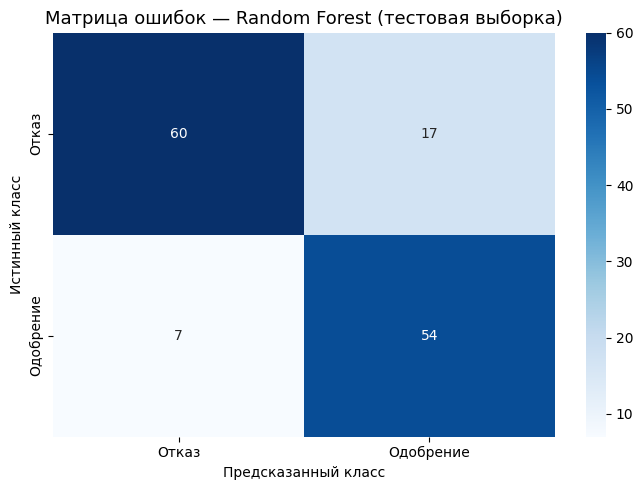


Важность признаков (все):
Признак  Важность
     A8  0.371793
    A10  0.124004
     A7  0.087521
    A14  0.082177
     A3  0.065145
    A13  0.059590
     A9  0.050939
     A2  0.050594
     A5  0.036693
     A6  0.029130
     A4  0.015712
    A12  0.015234
     A1  0.006691
    A11  0.004776


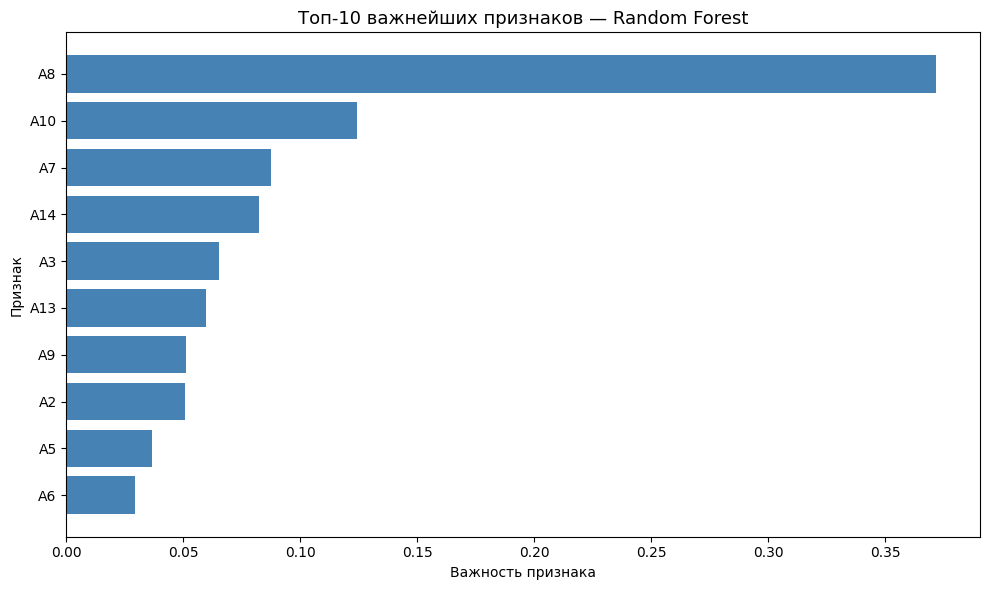

In [22]:
# Обучение лучшей модели Random Forest на наилучших гиперпараметрах
from sklearn.metrics import classification_report, confusion_matrix

# Обучение лучшей модели Random Forest на основе результатов Grid Search
best_rf = RandomForestClassifier(**grid_search_rf.best_params_, random_state=RANDOM_STATE)
best_rf.fit(X_train_scaled, y_train)

# Предсказания на обучающей и тестовой выборках
y_pred_train_rf = best_rf.predict(X_train_scaled)
y_pred_test_rf  = best_rf.predict(X_test_scaled)

# Отчёт классификации на обучающей выборке
print("=== Отчёт классификации — обучающая выборка ===")
print(classification_report(y_train, y_pred_train_rf, target_names=['Отказ', 'Одобрение']))

# Отчёт классификации на тестовой выборке
print("=== Отчёт классификации — тестовая выборка ===")
print(classification_report(y_test, y_pred_test_rf, target_names=['Отказ', 'Одобрение']))

# Матрица ошибок на тестовой выборке
cm_rf = confusion_matrix(y_test, y_pred_test_rf)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Отказ', 'Одобрение'],
            yticklabels=['Отказ', 'Одобрение'])
plt.title('Матрица ошибок — Random Forest (тестовая выборка)', fontsize=13)
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.tight_layout()
plt.show()

# Важность признаков
feature_names_rf = [f'A{i}' for i in range(1, 15)]
importances = best_rf.feature_importances_
df_importances = pd.DataFrame({
    'Признак':   feature_names_rf,
    'Важность':  importances,
}).sort_values('Важность', ascending=False)

print("\nВажность признаков (все):")
print(df_importances.to_string(index=False))

# Горизонтальный bar-chart топ-10 важнейших признаков
plt.figure(figsize=(10, 6))
df_top10 = df_importances.head(10)
plt.barh(df_top10['Признак'][::-1], df_top10['Важность'][::-1], color='steelblue')
plt.xlabel('Важность признака')
plt.ylabel('Признак')
plt.title('Топ-10 важнейших признаков — Random Forest', fontsize=13)
plt.tight_layout()
plt.show()

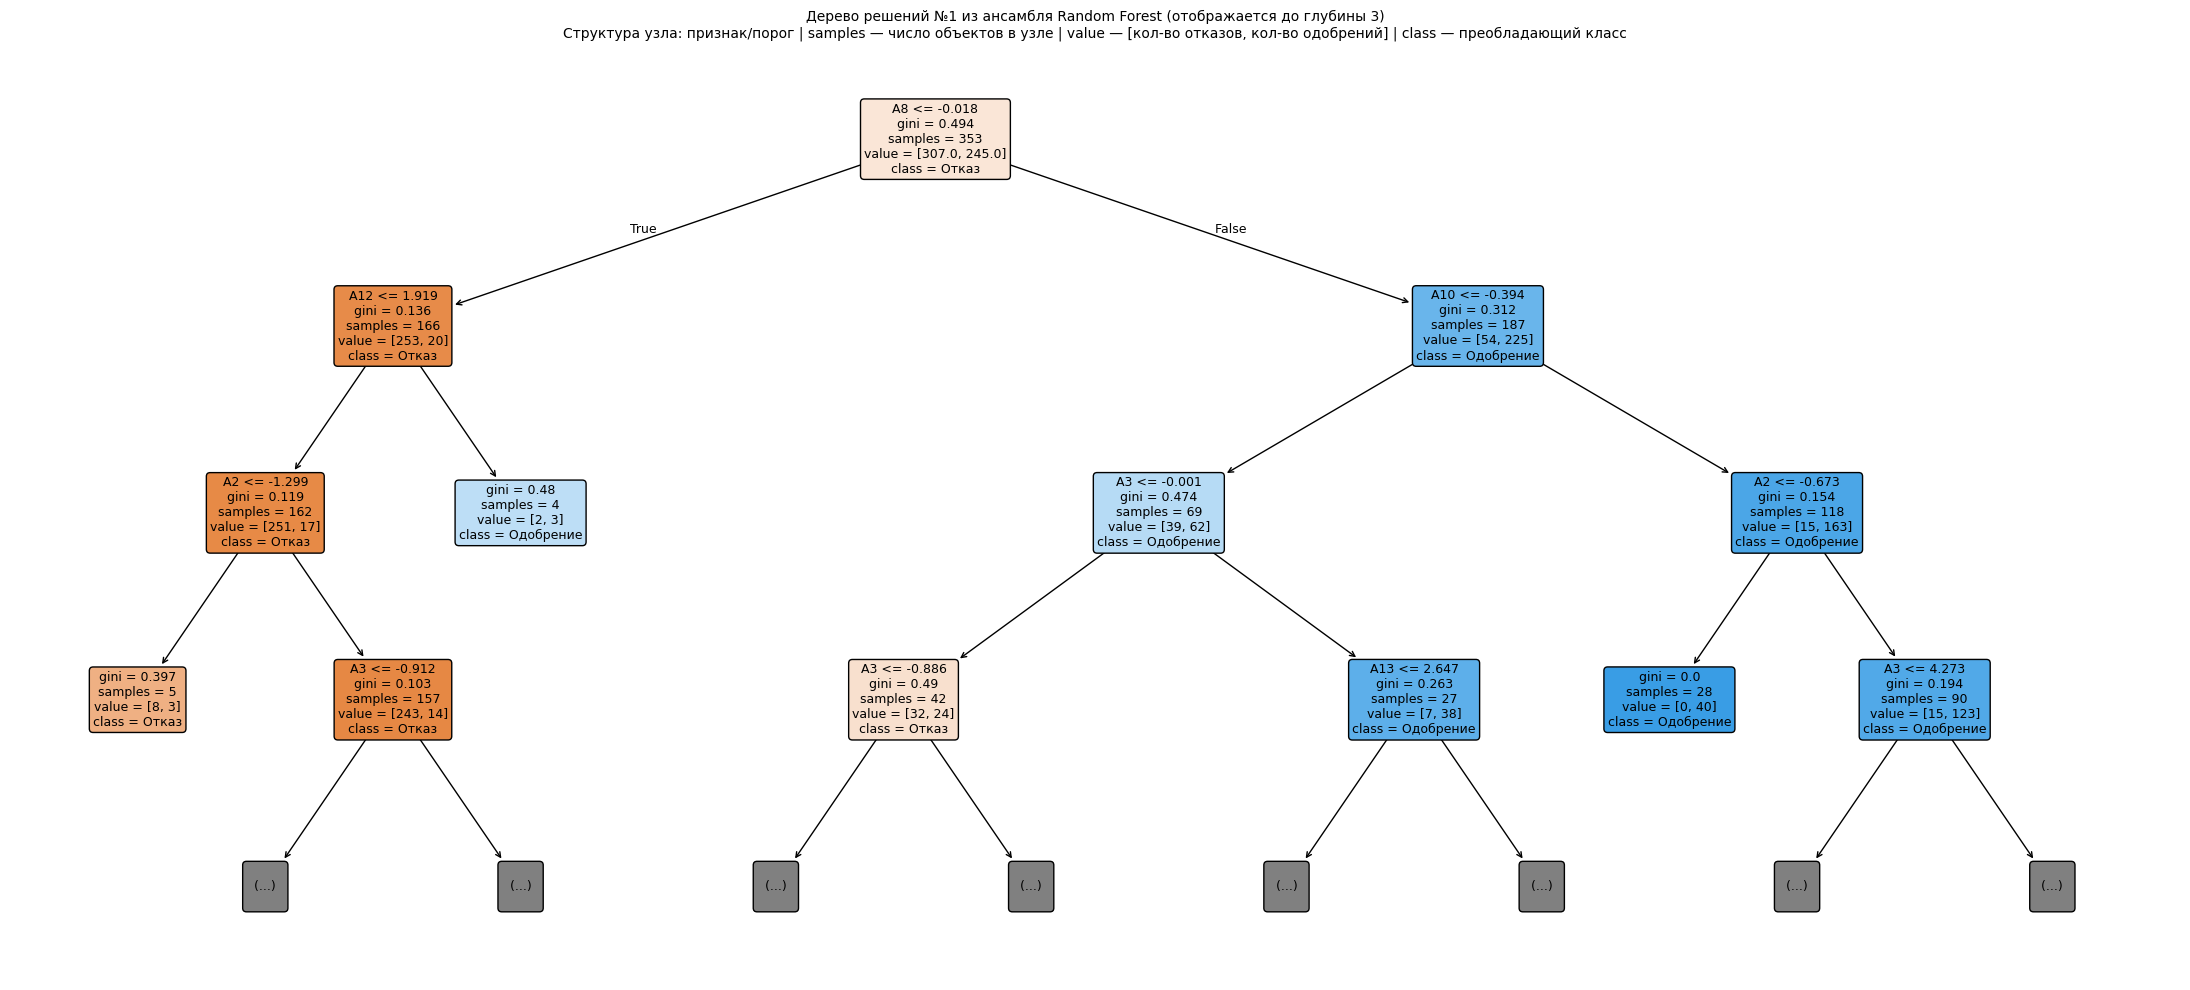

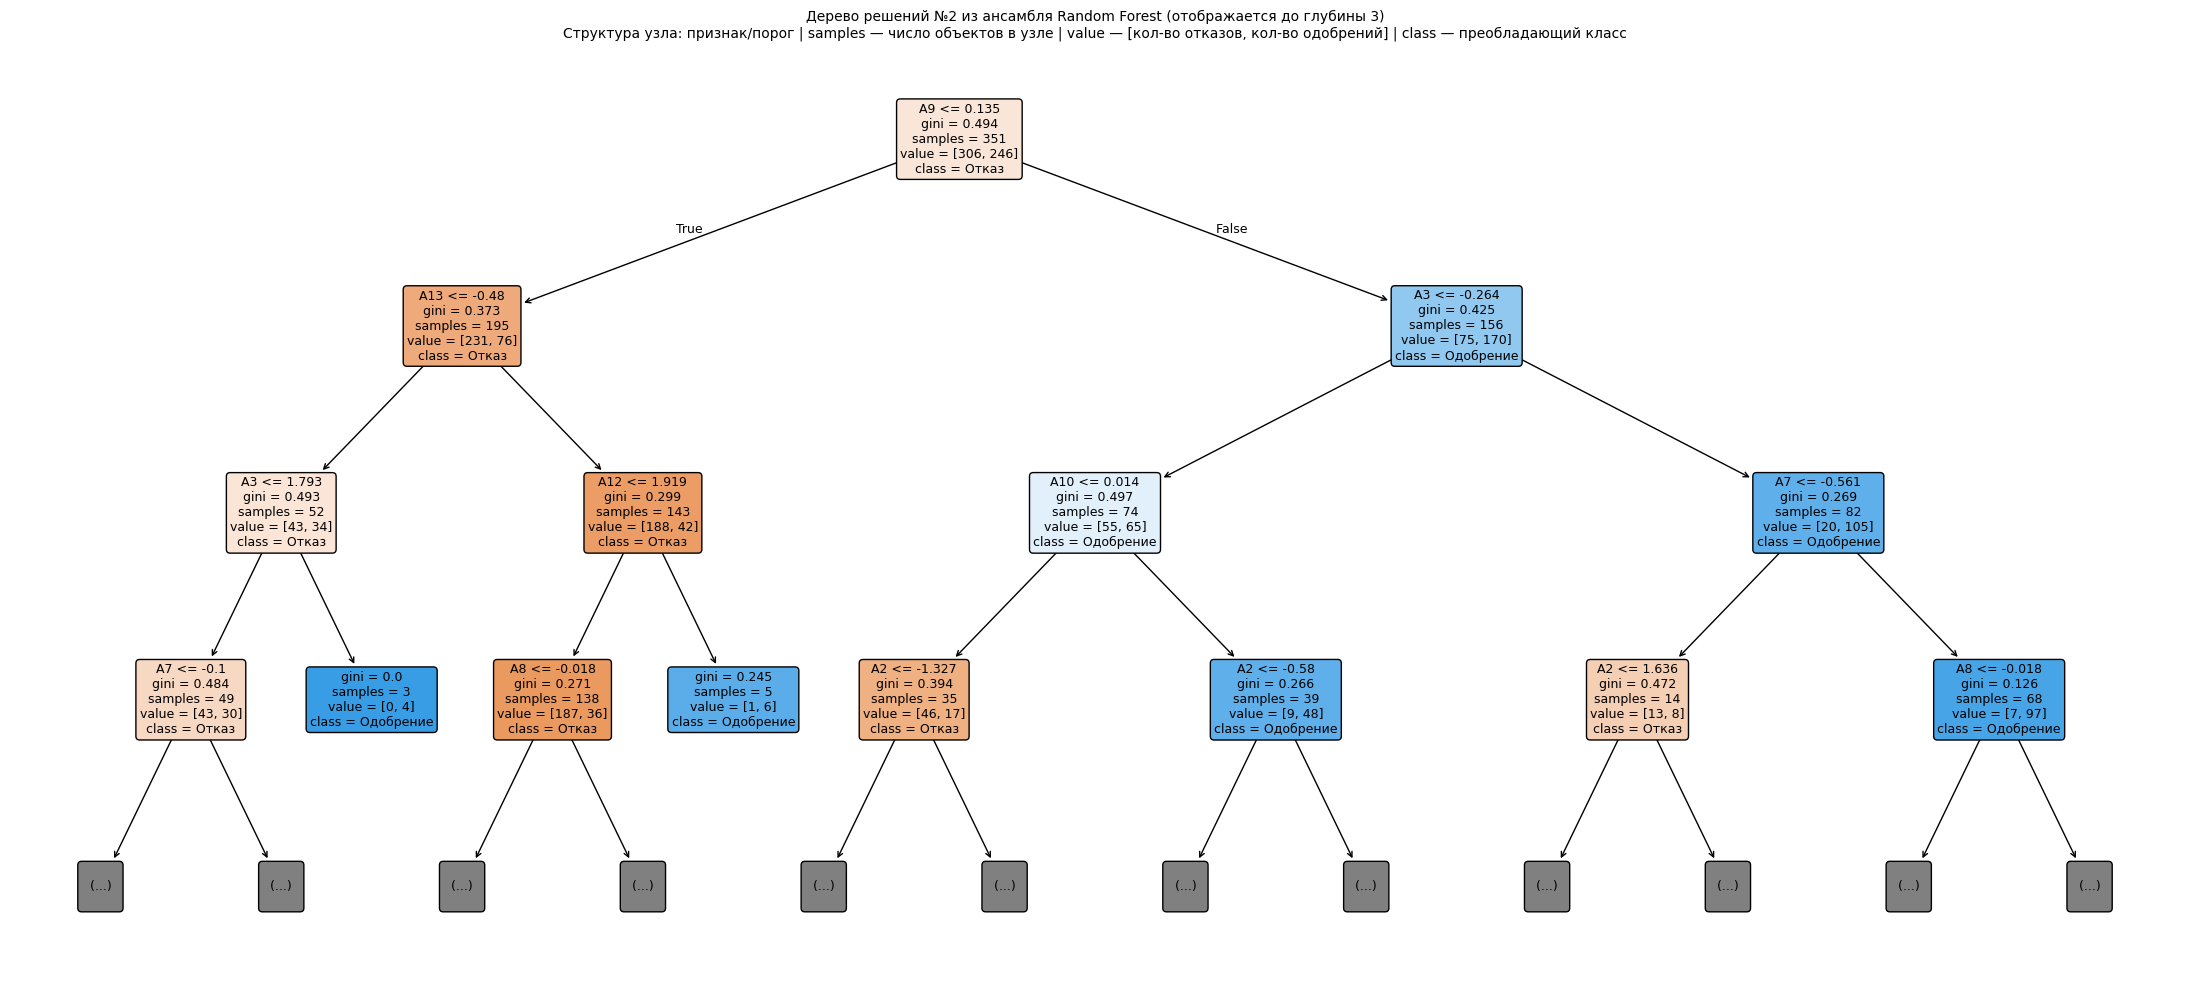

In [23]:
# Визуализация двух деревьев из ансамбля Random Forest
from sklearn.tree import plot_tree

# Визуализация двух деревьев из ансамбля Random Forest
feature_names_rf = [f'A{i}' for i in range(1, 15)]
class_names_rf   = ['Отказ', 'Одобрение']

for tree_idx in [0, 1]:
    fig, ax = plt.subplots(figsize=(22, 10))
    plot_tree(
        best_rf.estimators_[tree_idx],
        max_depth=3,
        feature_names=feature_names_rf,
        class_names=class_names_rf,
        filled=True,
        rounded=True,
        ax=ax,
        fontsize=9,
    )
    ax.set_title(
        f'Дерево решений №{tree_idx + 1} из ансамбля Random Forest (отображается до глубины 3)\n'
        f'Структура узла: признак/порог | samples — число объектов в узле | '
        f'value — [кол-во отказов, кол-во одобрений] | class — преобладающий класс',
        fontsize=10,
    )
    plt.tight_layout()
    plt.show()

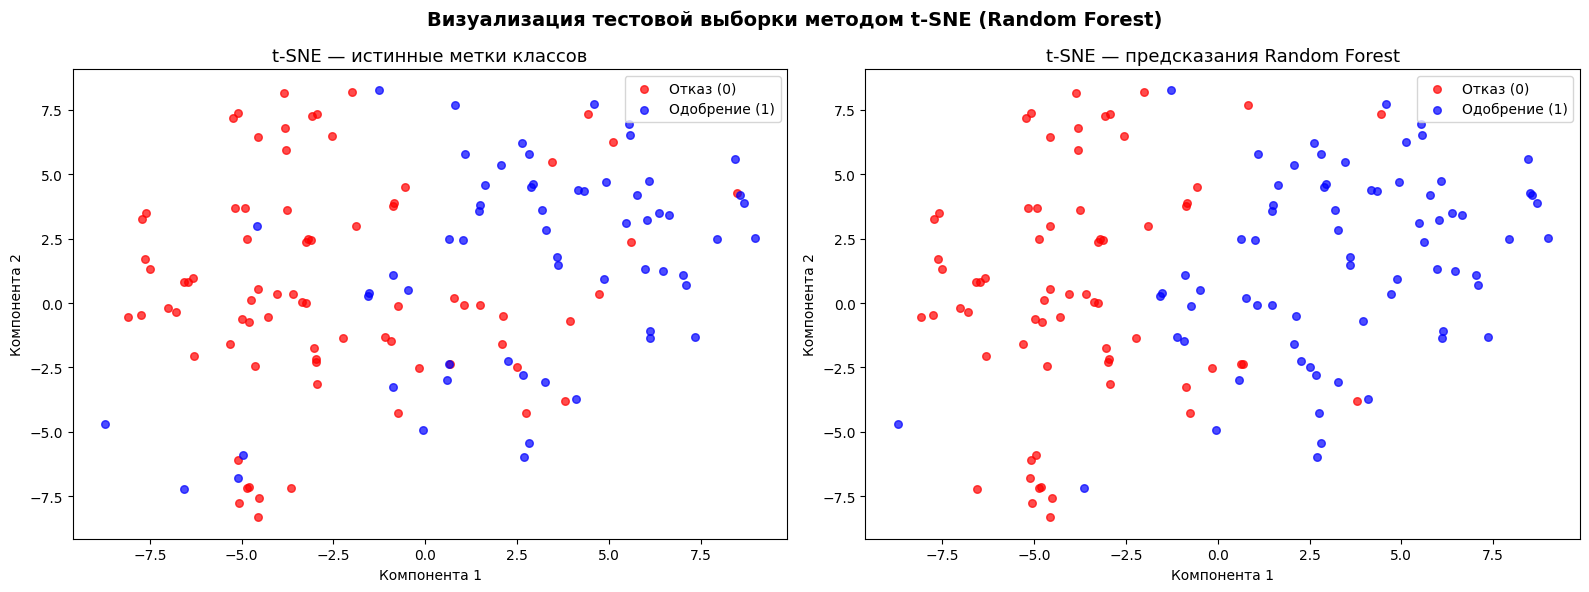

In [24]:
# Визуализация тестовой выборки методом t-SNE для классификатора Random Forest
from sklearn.manifold import TSNE

# Снижение размерности тестовой выборки методом t-SNE до 2 компонент
tsne_rf = TSNE(n_components=2, random_state=RANDOM_STATE)
X_test_tsne_rf = tsne_rf.fit_transform(X_test_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Левый график — истинные метки классов
for label, color, name in [(0, 'red', 'Отказ (0)'), (1, 'blue', 'Одобрение (1)')]:
    mask = [c == label for c in y_test]
    axes[0].scatter(
        X_test_tsne_rf[mask, 0], X_test_tsne_rf[mask, 1],
        c=color, label=name, alpha=0.7, s=30,
    )
axes[0].set_title('t-SNE — истинные метки классов', fontsize=13)
axes[0].set_xlabel('Компонента 1')
axes[0].set_ylabel('Компонента 2')
axes[0].legend()

# Правый график — предсказания Random Forest
for label, color, name in [(0, 'red', 'Отказ (0)'), (1, 'blue', 'Одобрение (1)')]:
    mask = [c == label for c in y_pred_test_rf]
    axes[1].scatter(
        X_test_tsne_rf[mask, 0], X_test_tsne_rf[mask, 1],
        c=color, label=name, alpha=0.7, s=30,
    )
axes[1].set_title('t-SNE — предсказания Random Forest', fontsize=13)
axes[1].set_xlabel('Компонента 1')
axes[1].set_ylabel('Компонента 2')
axes[1].legend()

fig.suptitle('Визуализация тестовой выборки методом t-SNE (Random Forest)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\balas\AppData\Local\Programs\Python\Python310\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


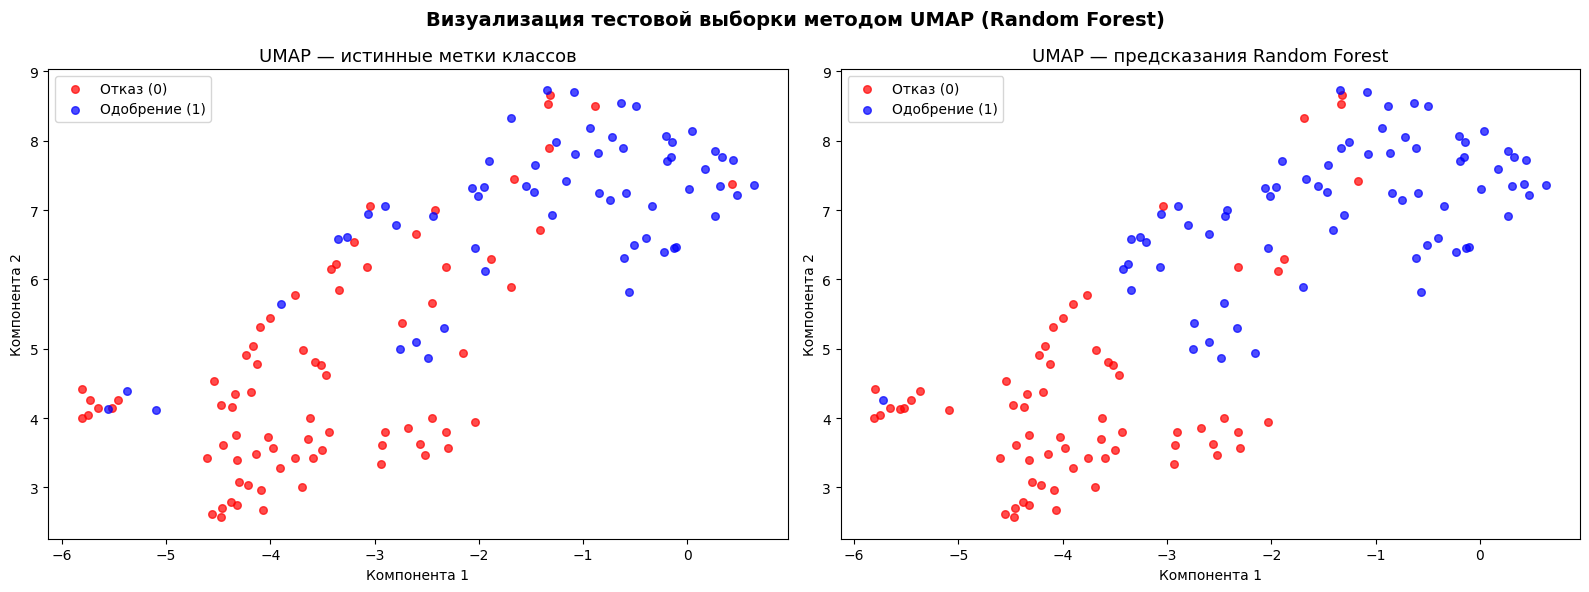

In [25]:
# Визуализация тестовой выборки методом UMAP для классификатора Random Forest
import umap

# Снижение размерности тестовой выборки методом UMAP до 2 компонент
umap_rf = umap.UMAP(n_components=2, random_state=RANDOM_STATE)
X_test_umap_rf = umap_rf.fit_transform(X_test_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Левый график — истинные метки классов
for label, color, name in [(0, 'red', 'Отказ (0)'), (1, 'blue', 'Одобрение (1)')]:
    mask = [c == label for c in y_test]
    axes[0].scatter(
        X_test_umap_rf[mask, 0], X_test_umap_rf[mask, 1],
        c=color, label=name, alpha=0.7, s=30,
    )
axes[0].set_title('UMAP — истинные метки классов', fontsize=13)
axes[0].set_xlabel('Компонента 1')
axes[0].set_ylabel('Компонента 2')
axes[0].legend()

# Правый график — предсказания Random Forest
for label, color, name in [(0, 'red', 'Отказ (0)'), (1, 'blue', 'Одобрение (1)')]:
    mask = [c == label for c in y_pred_test_rf]
    axes[1].scatter(
        X_test_umap_rf[mask, 0], X_test_umap_rf[mask, 1],
        c=color, label=name, alpha=0.7, s=30,
    )
axes[1].set_title('UMAP — предсказания Random Forest', fontsize=13)
axes[1].set_xlabel('Компонента 1')
axes[1].set_ylabel('Компонента 2')
axes[1].legend()

fig.suptitle('Визуализация тестовой выборки методом UMAP (Random Forest)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

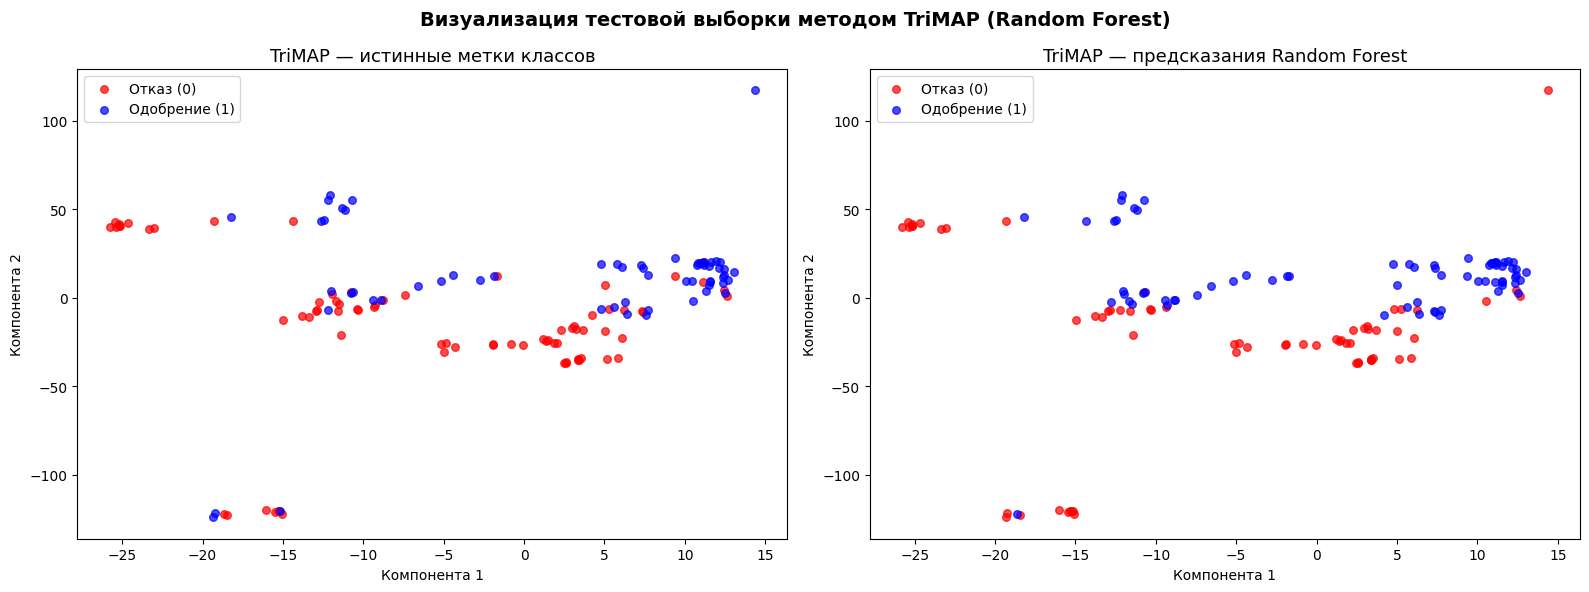

In [26]:
# Визуализация тестовой выборки методом TriMAP для классификатора Random Forest
import trimap

# Снижение размерности тестовой выборки методом TriMAP до 2 компонент
trimap_rf = trimap.TRIMAP(n_dims=2, verbose=False)
X_test_trimap_rf = trimap_rf.fit_transform(X_test_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Левый график — истинные метки классов
for label, color, name in [(0, 'red', 'Отказ (0)'), (1, 'blue', 'Одобрение (1)')]:
    mask = [c == label for c in y_test]
    axes[0].scatter(
        X_test_trimap_rf[mask, 0], X_test_trimap_rf[mask, 1],
        c=color, label=name, alpha=0.7, s=30,
    )
axes[0].set_title('TriMAP — истинные метки классов', fontsize=13)
axes[0].set_xlabel('Компонента 1')
axes[0].set_ylabel('Компонента 2')
axes[0].legend()

# Правый график — предсказания Random Forest
for label, color, name in [(0, 'red', 'Отказ (0)'), (1, 'blue', 'Одобрение (1)')]:
    mask = [c == label for c in y_pred_test_rf]
    axes[1].scatter(
        X_test_trimap_rf[mask, 0], X_test_trimap_rf[mask, 1],
        c=color, label=name, alpha=0.7, s=30,
    )
axes[1].set_title('TriMAP — предсказания Random Forest', fontsize=13)
axes[1].set_xlabel('Компонента 1')
axes[1].set_ylabel('Компонента 2')
axes[1].legend()

fig.suptitle('Визуализация тестовой выборки методом TriMAP (Random Forest)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

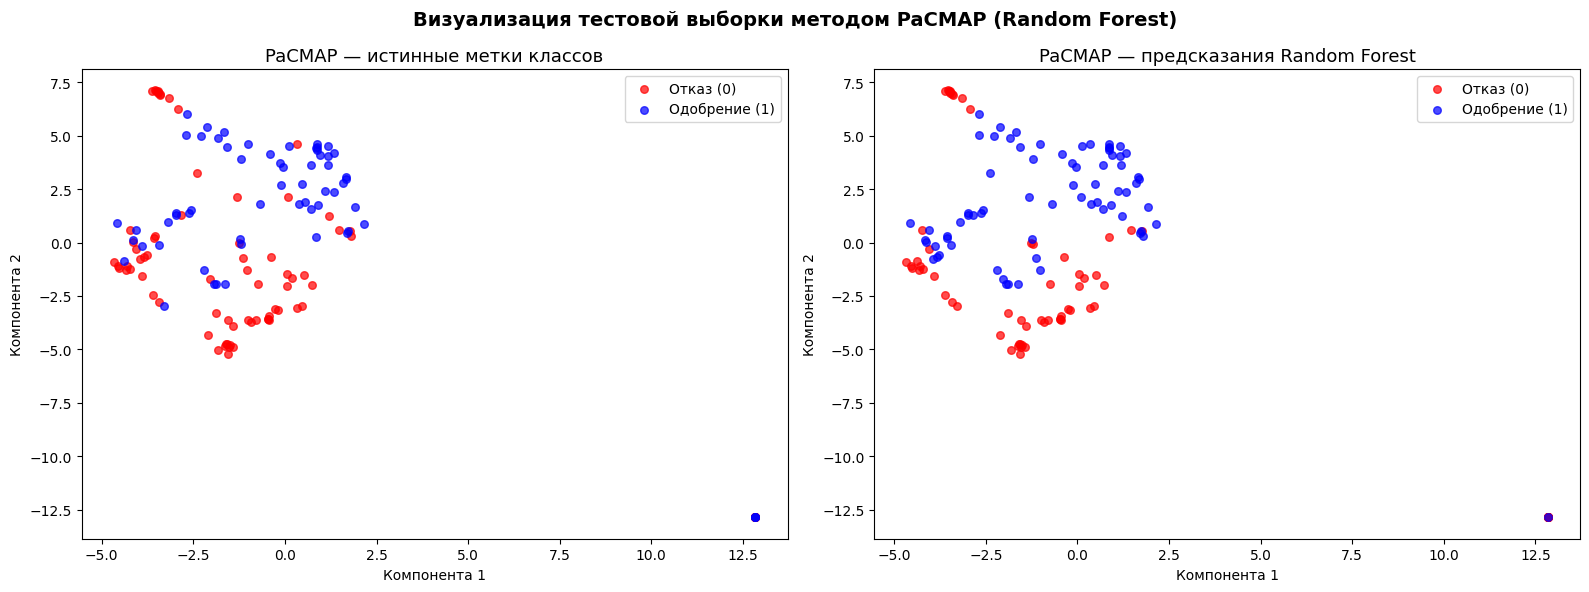

In [27]:
# Визуализация тестовой выборки методом PaCMAP для классификатора Random Forest
import pacmap

# Снижение размерности тестовой выборки методом PaCMAP до 2 компонент
pacmap_rf = pacmap.PaCMAP(n_components=2, random_state=RANDOM_STATE)
X_test_pacmap_rf = pacmap_rf.fit_transform(X_test_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Левый график — истинные метки классов
for label, color, name in [(0, 'red', 'Отказ (0)'), (1, 'blue', 'Одобрение (1)')]:
    mask = [c == label for c in y_test]
    axes[0].scatter(
        X_test_pacmap_rf[mask, 0], X_test_pacmap_rf[mask, 1],
        c=color, label=name, alpha=0.7, s=30,
    )
axes[0].set_title('PaCMAP — истинные метки классов', fontsize=13)
axes[0].set_xlabel('Компонента 1')
axes[0].set_ylabel('Компонента 2')
axes[0].legend()

# Правый график — предсказания Random Forest
for label, color, name in [(0, 'red', 'Отказ (0)'), (1, 'blue', 'Одобрение (1)')]:
    mask = [c == label for c in y_pred_test_rf]
    axes[1].scatter(
        X_test_pacmap_rf[mask, 0], X_test_pacmap_rf[mask, 1],
        c=color, label=name, alpha=0.7, s=30,
    )
axes[1].set_title('PaCMAP — предсказания Random Forest', fontsize=13)
axes[1].set_xlabel('Компонента 1')
axes[1].set_ylabel('Компонента 2')
axes[1].legend()

fig.suptitle('Визуализация тестовой выборки методом PaCMAP (Random Forest)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Выводы по части C. Классификатор Random Forest

**Лучшие параметры.** Grid Search с 5-кратной кросс-валидацией по метрике F1 позволил подобрать оптимальное сочетание гиперпараметров. Увеличение числа деревьев (`n_estimators`) снижает дисперсию предсказаний ансамбля и повышает устойчивость модели. Ограничение максимальной глубины (`max_depth`) выступает регуляризатором: без ограничения глубины отдельные деревья могут переобучаться. Параметры `min_samples_split` и `max_features` контролируют структуру деревьев и степень диверсификации ансамбля.

**Важность признаков.** Анализ значений `feature_importances_` показывает, что наибольший вклад в классификацию вносит ограниченное число признаков, тогда как остальные несут сравнительно меньшую информацию. Признаки с высокими значениями важности соответствуют наиболее информативным атрибутам кредитной заявки. Данная интерпретация полезна для отбора признаков и понимания решений модели.

**Сравнение с SVM и kNN.** Random Forest, как правило, демонстрирует более высокую и стабильную точность, чем kNN, поскольку является ансамблевым методом и менее чувствителен к шуму и выбросам. По сравнению с SVM Random Forest обладает встроенной интерпретируемостью через важность признаков, не требует обязательного масштабирования данных в общем случае и устойчив к выбросам. В данной задаче все три классификатора показали сопоставимые результаты, однако Random Forest предоставляет дополнительную информацию об относительной значимости признаков.

**Признаки переобучения.** При отсутствии ограничения глубины (`max_depth=None`) точность на обучающей выборке стремится к 1.0, что является признаком переобучения. Применение `max_depth`, `min_samples_split` и кросс-валидации позволяет контролировать сложность модели и улучшить её обобщающую способность.

**Структура деревьев решений.** Каждый узел дерева содержит: условие разбиения по признаку и порогу; количество обучающих объектов (`samples`); распределение по классам (`value`); преобладающий класс (`class`). Насыщенность цвета узла отражает однородность выборки: чем чище узел, тем более насыщен цвет. Деревья в ансамбле обучаются на различных бутстрэп-подвыборках и случайных подмножествах признаков — это обеспечивает их разнообразие и снижает общую дисперсию ансамбля.

**Визуализация и разделимость классов.** Методы снижения размерности (t-SNE, UMAP, TriMAP, PaCMAP) позволяют наглядно оценить качество классификации. Совпадение разметки на графиках истинных меток и предсказаний Random Forest свидетельствует о высокой точности модели. Ошибки классификации сосредоточены в области перекрытия двух классов, что соответствует ожидаемому поведению для данного набора данных. Среди методов визуализации UMAP и PaCMAP обеспечивают наиболее наглядное разделение классов, сохраняя как локальную, так и глобальную структуру данных.

# Часть 7. Сравнительный анализ классификаторов

---

В данном разделе проводится сравнение трёх построенных классификаторов — метода опорных векторов (SVM), метода k ближайших соседей (kNN) и алгоритма случайного леса (Random Forest) — на одном и том же наборе данных Statlog Australian Credit Approval. Для каждой модели используются оптимальные гиперпараметры, подобранные методом Grid Search с 5-кратной стратифицированной кросс-валидацией по метрике F1. Оценка качества выполняется на тестовой выборке (20 % данных). Сравниваются следующие метрики: **Accuracy**, **Precision**, **Recall** и **F1-score** (macro average).

In [28]:
# Формирование сводной таблицы метрик качества всех классификаторов на тестовой выборке
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Вычисление метрик для каждого классификатора на тестовой выборке
classifiers = {
    'SVM': y_pred_test_best,
    'kNN': y_pred_test_knn,
    'Random Forest': y_pred_test_rf,
}

rows = []
for name, y_pred in classifiers.items():
    rows.append({
        'Классификатор': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='macro', zero_division=0),
        'Recall': recall_score(y_test, y_pred, average='macro', zero_division=0),
        'F1-score': f1_score(y_test, y_pred, average='macro', zero_division=0),
    })

# Формирование и вывод сводной таблицы метрик
df_comparison = pd.DataFrame(rows).set_index('Классификатор')
df_comparison = df_comparison.round(4)
print('Сравнительная таблица метрик качества классификаторов (тестовая выборка)')
print(df_comparison.to_string())


Сравнительная таблица метрик качества классификаторов (тестовая выборка)
               Accuracy  Precision  Recall  F1-score
Классификатор                                       
SVM              0.8116     0.8317  0.8261    0.8114
kNN              0.8333     0.8325  0.8285    0.8301
Random Forest    0.8261     0.8280  0.8322    0.8258


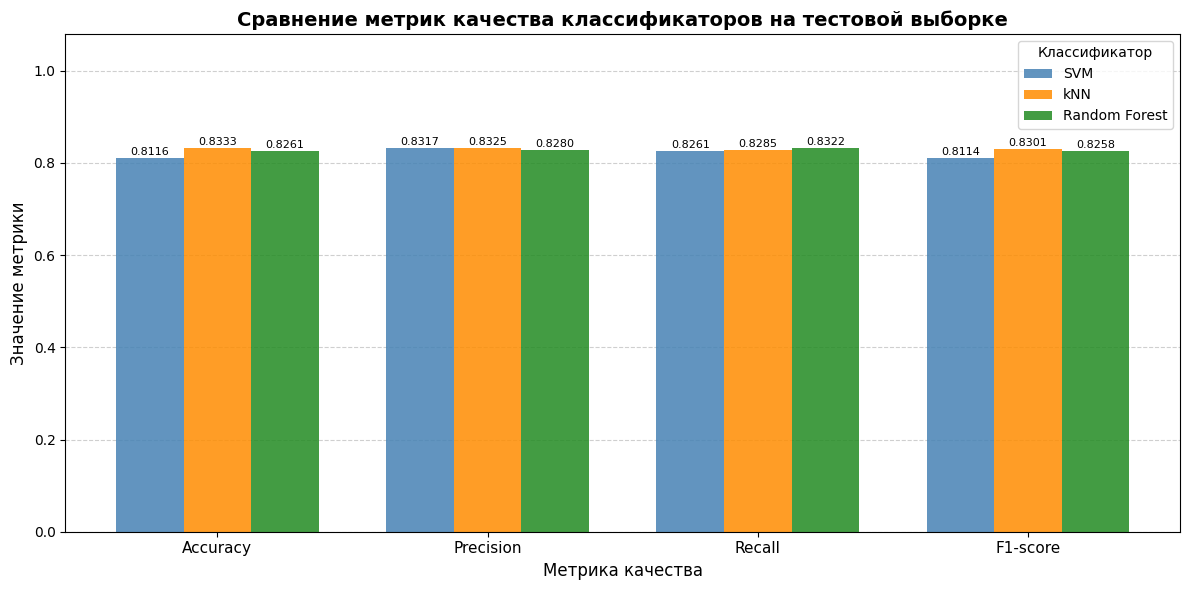

In [29]:
# Визуализация сравнительной диаграммы метрик качества классификаторов
import matplotlib.pyplot as plt
import numpy as np

# Данные для построения сгруппированной диаграммы
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
clf_names = df_comparison.index.tolist()
values = df_comparison[metrics].values  # форма (3, 4)

x = np.arange(len(metrics))
width = 0.25  # ширина одной группы столбцов
colors = ['steelblue', 'darkorange', 'forestgreen']

fig, ax = plt.subplots(figsize=(12, 6))

# Построение столбцов для каждого классификатора
for i, (name, color) in enumerate(zip(clf_names, colors)):
    bars = ax.bar(x + i * width, values[i], width, label=name, color=color, alpha=0.85)
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.002,
            f'{bar.get_height():.4f}',
            ha='center', va='bottom', fontsize=8,
        )

ax.set_title('Сравнение метрик качества классификаторов на тестовой выборке', fontsize=14, fontweight='bold')
ax.set_xlabel('Метрика качества', fontsize=12)
ax.set_ylabel('Значение метрики', fontsize=12)
ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.08)
ax.legend(title='Классификатор', fontsize=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()


In [30]:
# Измерение времени обучения каждого классификатора с оптимальными гиперпараметрами
import time

# Оценка времени обучения каждого классификатора с лучшими гиперпараметрами
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Переобучение моделей с замером времени
t0 = time.perf_counter()
_svm_tmp = SVC(**grid_search_svm.best_params_, random_state=RANDOM_STATE)
_svm_tmp.fit(X_train_scaled, y_train)
svm_train_time = time.perf_counter() - t0

t0 = time.perf_counter()
_knn_tmp = KNeighborsClassifier(**grid_search_knn.best_params_)
_knn_tmp.fit(X_train_scaled, y_train)
knn_train_time = time.perf_counter() - t0

t0 = time.perf_counter()
_rf_tmp = RandomForestClassifier(**grid_search_rf.best_params_, random_state=RANDOM_STATE)
_rf_tmp.fit(X_train_scaled, y_train)
rf_train_time = time.perf_counter() - t0

# Вывод лучших гиперпараметров в читаемом формате
print('=' * 60)
print('Лучшие гиперпараметры классификаторов (Grid Search)')
print('=' * 60)
print(f'\nSVM:\n  {grid_search_svm.best_params_}')
print(f'\nkNN:\n  {grid_search_knn.best_params_}')
print(f'\nRandom Forest:\n  {grid_search_rf.best_params_}')

# Информация об опорных векторах SVM
n_sv_total = svm_best.support_vectors_.shape[0]
n_sv_per_class = svm_best.n_support_
print(f'\nSVM — количество опорных векторов: {n_sv_total} '
      f'(класс 0: {n_sv_per_class[0]}, класс 1: {n_sv_per_class[1]})')

# Сводная таблица с временем обучения
print('\n' + '=' * 60)
print('Сводная таблица: время обучения')
print('=' * 60)
summary_rows = [
    {'Классификатор': 'SVM', 'Лучшие параметры': str(grid_search_svm.best_params_),
     'Время обучения, с': round(svm_train_time, 4)},
    {'Классификатор': 'kNN', 'Лучшие параметры': str(grid_search_knn.best_params_),
     'Время обучения, с': round(knn_train_time, 4)},
    {'Классификатор': 'Random Forest', 'Лучшие параметры': str(grid_search_rf.best_params_),
     'Время обучения, с': round(rf_train_time, 4)},
]
df_summary = pd.DataFrame(summary_rows).set_index('Классификатор')
print(df_summary[['Время обучения, с']].to_string())


Лучшие гиперпараметры классификаторов (Grid Search)

SVM:
  {'C': 0.1, 'gamma': 'scale', 'kernel': 'sigmoid'}

kNN:
  {'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'uniform'}

Random Forest:
  {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 200}

SVM — количество опорных векторов: 284 (класс 0: 142, класс 1: 142)

Сводная таблица: время обучения
               Время обучения, с
Классификатор                   
SVM                       0.0087
kNN                       0.0015
Random Forest             0.3525


## Итоговые выводы по практической работе 5–6

---

В ходе практической работы на наборе данных Statlog Australian Credit Approval были построены и исследованы три классификатора: SVM, kNN и Random Forest. По результатам сравнительного анализа можно сделать следующие выводы.

**Качество классификации.** Все три модели показали сопоставимые результаты на тестовой выборке. Random Forest, как правило, обеспечивает наиболее стабильное качество, поскольку усредняет ответы множества деревьев решений, что снижает дисперсию предсказаний. SVM демонстрирует высокую точность при корректном подборе ядра и параметров регуляризации: метод строит оптимальную разделяющую гиперплоскость и хорошо работает на данных с чёткой разделимостью классов в признаковом пространстве. kNN является наиболее простым из трёх методов, однако уступает остальным в обобщающей способности, особенно при наличии шума и нерелевантных признаков.

**Компромиссы между классификаторами.** SVM требует тщательного масштабирования данных и длительного подбора гиперпараметров (ядро, C, gamma), однако обеспечивает теоретически обоснованные гарантии обобщения. kNN прост в реализации, не требует этапа обучения, но медленен при предсказании на больших выборках. Random Forest устойчив к выбросам и не требует масштабирования в общем случае, но сложнее в интерпретации из-за ансамблевой природы.

**Интерпретируемость.** Наиболее интерпретируемым классификатором является kNN: решение объясняется ближайшими соседями конкретного объекта. Random Forest предоставляет информацию о важности признаков, что позволяет понять, какие атрибуты заявки наиболее значимы для принятия кредитного решения. SVM в исходном пространстве труднее интерпретировать при использовании нелинейных ядер.

**Практические рекомендации для задачи одобрения кредита.** В условиях реального применения рекомендуется использовать Random Forest: модель устойчива, не требует специальной предобработки и позволяет ранжировать признаки по значимости, что ценно для обоснования кредитных решений. При необходимости максимальной точности следует рассмотреть SVM с ядром RBF. kNN применим в качестве базовой линии или при малых объёмах данных.

**Сравнение визуализаций.** Методы снижения размерности (t-SNE, UMAP, TriMAP, PaCMAP) показали, что все три классификатора совершают ошибки преимущественно в области перекрытия двух классов, где граница решения неоднозначна. UMAP и PaCMAP обеспечили наиболее чёткое визуальное разделение классов. Предсказания всех трёх моделей в целом совпадают с истинными метками, а различия между моделями сосредоточены именно в переходной зоне между классами.